# 复贷wa泳道下单uplift模型

In [1]:
from impala.dbapi import connect
import getpass
import pandas as pd
import numpy as np
#email_address = getpass.getpass('enter_email:')
# email='邮箱前缀'
email= 'zhangquanyu'
# passwd = 'oa密码'
passwd = 'Y13u&quan28'

In [2]:
## 1.连接数据库
def get_conn(db_host, port, authMechanism, user, password):
        return connect(host=db_host,
                       port=port,
                       auth_mechanism=authMechanism,
                       user=user,
                       password=password
)

In [3]:
## 2.读取数据库数据并生成df格式
def read_data(sql):
    cursor.execute(sql)
    datas = cursor.fetchall()
    cols = cursor.description
    col=[]
    for i in cols:
        
        col.append(i[0])
    df = pd.DataFrame(np.array(datas),columns=col)

    print('读取数据库成功')
    return df


In [4]:
# 3.海外机器  印尼 
cursor = get_conn(db_host = '172.29.245.53', port = 10000, authMechanism = 'LDAP', user=email, password=passwd).cursor()
# 菲律宾 
# cursor = get_conn(db_host='172.20.143.245', port=10000, authMechanism='LDAP', 
#                   user=email, password=passwd).cursor()

In [5]:
import os

# 在Jupyter Notebook中获取当前工作目录
current_path = os.getcwd()
print(f"当前工作目录: {current_path}")

当前工作目录: /mnt/workspace/02_reloan_wa_loansucc_uplift


In [6]:
import time
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import lightgbm as lgb
from xgboost import plot_importance
from sklearn.model_selection import train_test_split as tts,GridSearchCV
from sklearn.metrics import accuracy_score as accuracy,recall_score as recall,roc_auc_score,roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
# from sklearn.externals import joblib
from sklearn.ensemble import RandomForestClassifier
# import Plot_AucLiftKs as plt_alk
import os
import matplotlib as mpl
import seaborn as sns
import joblib
import datetime

In [7]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_predict
from lightgbm import LGBMClassifier
# from lightgbm import LGBMRegressor
import logging
# 设置日志级别为WARNING，屏蔽掉INFO级别以下的日志信息
logging.basicConfig(level=logging.WARNING)

## 导数

In [ ]:
## ETL 特征表

In [ ]:
df_ft_ios = pd.read_parquet("/data/etl_data/phi_etl_file/20251112/3000011658")
df_ft_ios = df_ft_ios.drop(['userId','orderId','traceId'],axis=1)
# df_ft_ios = df_ft_ios.rename(columns={'traceId':'first_trace_id',
#         'modelId_200000655':'xujie_person_prob_v1_comm_xujiev6',
#         'modelId_200000632':'xujie_new_add_risk_model_v6',
#                                      })
df_ft_ios.shape

In [ ]:
df_ft_ios.dtypes

In [ ]:
df_ft_ios2 = pd.read_parquet("/data/etl_data/phi_etl_file/20251112/3000011659")
df_ft_ios2 = df_ft_ios2.drop(['userId','orderId','traceId'],axis=1)
# df_ft_ios = df_ft_ios.rename(columns={'traceId':'first_trace_id',
#         'modelId_200000655':'xujie_person_prob_v1_comm_xujiev6',
#         'modelId_200000632':'xujie_new_add_risk_model_v6',
#                                      })
df_ft_ios2.shape

In [ ]:
df_ft_ios2.dtypes

In [ ]:
feature_cols = [col for col in df_ft_ios.columns] ## =df_ft_ios.columns
df_feats = pd.DataFrame(feature_cols, columns=['feature_name'])

In [ ]:
# df_feats['source'] = df_feats.apply(lambda x:x.split('___')[0])
# # ft_short31['source'] = ft_short31['source'].apply(lambda x:x if x not in app_sub_score+sms_sub_score
# #                                                  else 'null')
# df_feats['name'] = df_feats.apply(lambda x:'___'.join(x.split('___')[1:]))

In [ ]:
df_feats['source'] = df_feats['feature_name'].apply(lambda x: x.split('___')[0])
df_feats['name'] = df_feats['feature_name'].apply(lambda x: '___'.join(x.split('___')[1:]))
print("分列完成！")
df_feats.to_csv('./df_feats_list.csv')

In [ ]:
feature_cols2 = [col for col in df_ft_ios2.columns]
df_feats2 = pd.DataFrame(feature_cols2, columns=['feature_name'])

In [ ]:
df_feats2['source'] = df_feats2['feature_name'].apply(lambda x: x.split('___')[0])
df_feats2['name'] = df_feats2['feature_name'].apply(lambda x: '___'.join(x.split('___')[1:]))
print("分列完成！")
df_feats2.to_csv('./df_feats_list2.csv')

In [ ]:
df.shape

In [ ]:
df.dtypes

In [ ]:
# ## 取全量样本表 hive表
# sql1 = "select * from risk_data.tmp_yzq_reloan_wa_payout_uplift_feats_all"
# df = read_data(sql1)
# ##字段名处理
# df.columns = df.columns.str.replace('tmp_yzq_reloan_wa_payout_uplift_feats_all.', '')
# df.to_parquet('/data/public_data/cpu2/tmp_yzq_reloan_wa_payout_uplift_feats_all',compression='gzip',index=False)

In [20]:
## 取全量样本表 hive表
sql1 = "select * from risk_data.tmp_yzq_reloan_wa_payout_uplift_feats_jq"
df = read_data(sql1)
##字段名处理
df.columns = df.columns.str.replace('tmp_yzq_reloan_wa_payout_uplift_feats_jq.', '')
df.to_parquet('/data/public_data/cpu2/tmp_yzq_reloan_wa_payout_uplift_feats_jq',compression='gzip',index=False)

读取数据库成功


In [40]:
df.shape

(60913, 1349)

In [32]:
## 取全量样本表 hive表
sql1 = "select * from risk_data.tmp_yzq_reloan_wa_payout_uplift_feats_xj"
df2 = read_data(sql1)
##字段名处理
df2.columns = df2.columns.str.replace('tmp_yzq_reloan_wa_payout_uplift_feats_xj.', '')
df2.to_parquet('/data/public_data/cpu2/tmp_yzq_reloan_wa_payout_uplift_feats_xj',compression='gzip',index=False)

读取数据库成功


In [39]:
df2.shape

(60000, 1349)

In [8]:
## 取全量样本表 hive表
sql1 = "select * from risk_data.idn_3000042330"
df3 = read_data(sql1)
##字段名处理
df3.columns = df3.columns.str.replace('tmp_yzq_reloan_wa_payout_uplift_feats_20w.', '')
df3.to_parquet('/data/public_data/cpu2/tmp_yzq_reloan_wa_payout_uplift_feats_20w',compression='gzip',index=False)

HiveServer2Error: Invalid OperationHandle: OperationHandle [opType=EXECUTE_STATEMENT, getHandleIdentifier()=5c3ebbb1-b14f-43d7-9ceb-8a8540a86cfa]

In [ ]:
## 取20W抽样特征表的对应label
sql1 = "select * from risk_data.tmp_yzq_reloan_wa_loansucc_yangben_t1_base_rand_label"
df3 = read_data(sql1)
##字段名处理
df3.columns = df3.columns.str.replace('tmp_yzq_reloan_wa_loansucc_yangben_t1_base_rand_label.', '')
df3.to_parquet('/data/public_data/cpu2/tmp_yzq_reloan_wa_loansucc_yangben_t1_base_rand_label',compression='gzip',index=False)

In [9]:
## 取全量样本表
df_ft_ios = pd.read_parquet("/data/etl_data_overseas/20251215/3000042330/data/")
df_ft_ios = df_ft_ios.drop(['orderId','traceId'],axis=1)
# df_ft_ios = df_ft_ios.rename(columns={'traceId':'first_trace_id',
#         'modelId_200000655':'xujie_person_prob_v1_comm_xujiev6',
#         'modelId_200000632':'xujie_new_add_risk_model_v6',
#                                      })
df_ft_ios.shape

FileNotFoundError: [Errno 2] No such file or directory: '/data/etl_data_overseas/20251215/3000042330/data/'

In [ ]:
# ## 取全量样本表
# df_ft_ios = pd.read_parquet("/data/etl_data/phi_etl_file/20251114/3000011693")
# df_ft_ios = df_ft_ios.drop(['userId','orderId','traceId'],axis=1)
# # df_ft_ios = df_ft_ios.rename(columns={'traceId':'first_trace_id',
# #         'modelId_200000655':'xujie_person_prob_v1_comm_xujiev6',
# #         'modelId_200000632':'xujie_new_add_risk_model_v6',
# #                                      })
# df_ft_ios.shape

In [ ]:
# df_ft_ios.dtypes

## 拼表

In [ ]:
df = df.copy()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
df_ft_ios = df_ft_ios.copy()
for col in df_ft_ios.select_dtypes(include=['object']).columns:
    df_ft_ios[col] = pd.to_numeric(df_ft_ios[col], errors='coerce')

In [ ]:
df_ft_ios2 = df_ft_ios2.copy()
for col in df_ft_ios2.select_dtypes(include=['object']).columns:
    df_ft_ios2[col] = pd.to_numeric(df_ft_ios2[col], errors='coerce')

In [34]:
## 关联

In [ ]:
dff =pd.merge(df_ft_ios,df,## on=['loanAccountId','time_stamp']
              left_on=['loanAccountId', 'time_stamp'],
              right_on=['loan_account_id', 'assign_timestamp']
              ,how='left')

In [ ]:
dff2 =pd.merge(dff,df_ft_ios2,## on=['loanAccountId','time_stamp']
              left_on=['loanAccountId', 'time_stamp'],
              right_on=['loanAccountId', 'time_stamp']
              ,how='left')

In [ ]:
df_ft_ios.shape

In [ ]:
dff.shape

In [ ]:
dff2.shape

In [ ]:
dff

In [ ]:
## 全量样本表拼表（label、特征）

In [ ]:
df_ft_ios = df_ft_ios.copy()
for col in df_ft_ios.select_dtypes(include=['object']).columns:
    df_ft_ios[col] = pd.to_numeric(df_ft_ios[col], errors='coerce')

In [ ]:
df_label = df_label.copy()
for col in df_label.select_dtypes(include=['object']).columns:
    df_label[col] = pd.to_numeric(df_label[col], errors='coerce')

In [ ]:
dff =pd.merge(df_ft_ios,df_label,## on=['loanAccountId','time_stamp']
              left_on=['loanAccountId', 'time_stamp'],
              right_on=['loan_account_id', 'assign_timestamp']
              ,how='left')

In [ ]:
dff.dtypes

In [ ]:
dff

In [ ]:
dff.to_parquet('/data/public_data/cpu4/tmp_yzq_repay_model_yangben_train',compression='gzip',index=False)

In [ ]:
## 按行合并数据集

In [44]:
dff = pd.concat([df, df2], axis=0)

In [45]:
dff.shape

(120913, 1349)

In [47]:
dff.to_parquet('/data/public_data/cpu2/tmp_yzq_reloan_wa_payout_uplift_feats_rand',compression='gzip',index=False)

## EDA、IV

In [22]:
## IV
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
import pandas as pd
import os 

CUT_BIN = 10

def calcKSOutput(y_prob, y_test, ks_file, output_path):
    data = pd.DataFrame({'score':y_prob, 'bad': y_test})
    data['bucket'] = pd.qcut(data.score, CUT_BIN, retbins=False, duplicates='drop')
    
    for_ks = data.groupby('bucket').agg({'bad':np.sum,
                                        'score':'count'
                                        })
    for_ks = for_ks.rename(columns = {'bad':'Target','score':'Count'})
    for_ks.reset_index(inplace=True)
    for_ks.sort_values(by='bucket',ascending=False,inplace=True)
    for_ks['No_target'] = for_ks['Count'] - for_ks['Target']
    for_ks['Bad_rate'] = for_ks['Target']/for_ks['Count']
    for_ks['Cum_tgt'] = for_ks['Target'].cumsum()/sum(for_ks['Target'])
    for_ks['Cum_notgt'] = for_ks['No_target'].cumsum()/sum(for_ks['No_target'])
    for_ks['tgt_Dist'] = for_ks['Target']/sum(for_ks['Target'])
    for_ks['lift'] = for_ks['Bad_rate']/(sum(for_ks['Target'])*1.0/sum(for_ks['count']))
    for_ks['KS'] = for_ks['Cum_tgt'] - for_ks['Cum_notgt']
    for_ks['Decile'] = range(1,len(for_ks)+1)
    for_ks.loc[len(for_ks)] = ['', sum(for_ks['Target']),sum(for_ks['count']),sum(for_ks['No_target']),'','','','','',max(for_ks['KS']),'overall']
    for_ks[['Decile','bucket','Count','Target','No_target','Bad_rate','Cum_tgt','Cum_notgt','tgt_Dist','lift','KS']].to_csv(output_path + ks_file+'.csv',encoding='latin-1',index=None)
    
    Cum_tgt = list(for_ks['Cum_tgt'])[:-1]
    Cum_notgt = list(for_ks['Cum_notgt'])[:-1]
    KS_value = ks_2samp(y_prob[y_test==1], y_prob[y_test!=1]).statistic
    #outputKSFigue(Cum_tgt,Cum_notgt,ks_file,KS_value,output_path)
    print('KS value %0.3f' %(KS_value))

def mono_bin(Y,X,n=10):
    df1 = pd.DataFrame({"X": X, "Y": Y})
    justmiss = df1[['X','Y']][df1.X.isnull()]
    notmiss = df1[['X','Y']][df1.X.notnull()]
    
    # Use pd.qcut with duplicates='drop' to handle duplicate values
    bins = pd.qcut(notmiss.X, n, duplicates='drop')
    
    d1 = pd.DataFrame({"X":notmiss.X, "Y":notmiss.Y, "Bucket": bins})
    d2 = d1.groupby('Bucket',as_index=True)
    
    d3 = pd.DataFrame({}, index=[])
    d3['MIN_VALUE'] = d2.min().X
    d3['MAX_VALUE'] = d2.max().X
    d3['COUNT'] = d2.count().Y
    d3['EVENT'] = d2.sum().Y
    d3['NONEVENT'] = d2.count().Y - d2.sum().Y
    d3 = d3.reset_index(drop=True)
    
    if len(justmiss.index) >0:
        d4 = pd.DataFrame({'MIN_VALUE':'NULL'}, index=[0])
        d4['MAX_VALUE'] = 'NULL'
        d4['COUNT'] = justmiss.count().Y
        d4['EVENT'] = justmiss.sum().Y
        d4['NONEVENT'] = justmiss.count().Y - justmiss.sum().Y
        
    d3['EVENT_RATE'] = d3.EVENT/d3.COUNT
    d3['NON_EVENT_RATE'] = d3.NONEVENT/d3.COUNT
    d3['DIST_EVENT'] = d3.EVENT/d3.sum().EVENT
    d3['DIST_NON_EVENT'] = d3.NONEVENT/d3.sum().NONEVENT
    d3['WOE'] = np.log(d3.DIST_EVENT/d3.DIST_NON_EVENT)
    d3['IV'] = (d3.DIST_EVENT - d3.DIST_NON_EVENT) * np.log(d3.DIST_EVENT/d3.DIST_NON_EVENT)
    d3['VAR_NAME'] = "VAR"
    d3 = d3[['VAR_NAME','MIN_VALUE','MAX_VALUE','COUNT','EVENT','EVENT_RATE','NONEVENT','NON_EVENT_RATE','DIST_EVENT','DIST_NON_EVENT','WOE','IV']]
    d3 = d3.replace([np.inf,-np.inf], 0)
    d3.IV = d3.IV.sum()
    return(d3)

def char_bin(Y,X):
    df1 = pd.DataFrame({"X":X, "Y":Y})
    justmiss = df1[['X','Y']][df1.X.isnull()]
    notmiss  = df1[['X','Y']][df1.X.notnull()]
#     fillmiss = df1[['X','Y']].fillna(-9999)
    d2 = notmiss.groupby('X',as_index=True)
    
    d3 = pd.DataFrame({}, index=[])
    d3['COUNT'] = d2.count().Y
    d3['MIN_VALUE'] = d2.sum().Y.index
    d3['MAX_VALUE'] = d3['MIN_VALUE']
    d3['EVENT'] = d2.sum().Y
    d3['NONEVENT'] = d2.count().Y - d2.sum().Y
    
    if len(justmiss.index) >0:
        d4 = pd.DataFrame({'MIN_VALUE':'NULL'}, index=[0])
        d4['MAX_VALUE'] = 'NULL'
        d4['COUNT'] = justmiss.count().Y
        d4['EVENT'] = justmiss.sum().Y
        d4['NONEVENT'] = justmiss.count().Y - justmiss.sum().Y
        d3 = d3.append(d4,ignore_index=True)
        
    d3['EVENT_RATE'] = d3.EVENT/d3.COUNT
    d3['NON_EVENT_RATE'] = d3.NONEVENT/d3.COUNT
    d3['DIST_EVENT'] = d3.EVENT/d3.sum().EVENT
    d3['DIST_NON_EVENT'] = d3.NONEVENT/d3.sum().NONEVENT
    d3['WOE'] = np.log(d3.DIST_EVENT/d3.DIST_NON_EVENT)
    d3['IV'] = (d3.DIST_EVENT - d3.DIST_NON_EVENT) * np.log(d3.DIST_EVENT/d3.DIST_NON_EVENT)
    d3['VAR_NAME'] = "VAR"
    d3 = d3[['VAR_NAME','MIN_VALUE','MAX_VALUE','COUNT','EVENT','EVENT_RATE','NONEVENT','NON_EVENT_RATE','DIST_EVENT','DIST_NON_EVENT','WOE','IV']]
    d3 = d3.replace([np.inf,-np.inf], 0)
    d3.IV = d3.IV.sum()
    d3 = d3.reset_index(drop=True)
    return(d3)

def data_vars(X, y, max_bin=10):
    iv_df = pd.DataFrame()
    count = 0
    for i in range(len(X.columns)):
        # print(X.columns[i])
        conv = mono_bin(y, X[X.columns[i]], max_bin)
        conv["VAR_NAME"] = X.columns[i]
        count = count + 1

        # Handle divide-by-zero issues
        conv.loc[conv["DIST_NON_EVENT"] == 0, "DIST_NON_EVENT"] = 1e-10

        if count == 0:
            iv_df = conv
        else:
            iv_df = pd.concat([iv_df, conv], ignore_index=True)

    iv = pd.DataFrame({'IV': iv_df.groupby('VAR_NAME')['IV'].max()})
    iv = iv.reset_index()

    return iv_df, iv

def get_iv_result(X,y):
    max_bin = 10
    return data_vars(X,y,max_bin)


In [61]:
auth_eda_1=dff.describe()
auth_eda_1.to_csv('./tmp_feas_v1_edd.csv',header=True, index=False)

In [52]:
dff.select_dtypes(include=['object']).columns.tolist()

[]

In [95]:
excluded_features = ['user_id', 'first_notif_create_date', 'exp_flag', 'group_flag']
features = [i for i in dff.columns if i not in excluded_features]

for col in features:
    if dff[col].dtype == 'object':  # 只处理指定范围内的object类型
        dff[col] = pd.to_numeric(dff[col], errors='coerce')

In [97]:
dff.dtypes

user_id                        int64
first_notif_create_date       object
exp_flag                      object
group_flag                    object
treatment                      int64
                              ...   
t60t180_wa_failed_cnt_rt     float64
t60t360_wa_failed_cnt_rt     float64
t90t180_wa_failed_cnt_rt     float64
t90t360_wa_failed_cnt_rt     float64
t180t360_wa_failed_cnt_rt    float64
Length: 1349, dtype: object

In [98]:
dff.to_parquet('/data/public_data/cpu2/tmp_yzq_reloan_wa_payout_uplift_feats_rand',compression='gzip',index=False)

In [53]:
d_predict=dff.drop(columns=[
    'user_id', 'first_notif_create_date','exp_flag', 'group_flag',
 'y_t0',
 'y_t3',
 'y_t7',
 'y_qiepian_t7'
], axis=1) 
d_test = dff['y_t3']
iv_df, iv = get_iv_result(d_predict, d_test)

# 准备写入的CSV文件
iv_df.to_csv('./IV_tmp_feas_v1_df.csv',\
             header=True,sep=',',index=True,encoding='utf-8-sig')
print("Done")

/root/.pyenv/versions/3.6.5/lib/python3.6/site-packages/pandas/core/series.py:726: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/root/.pyenv/versions/3.6.5/lib/python3.6/site-packages/pandas/core/series.py:726: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Done


In [54]:
dff['y_t3'].value_counts()

0    101952
1     18961
Name: y_t3, dtype: int64

## 训练模型分（Mob2 d7）

In [8]:
dff=pd.read_parquet('/data/public_data/cpu2/tmp_yzq_reloan_wa_payout_uplift_feats_rand')

In [ ]:
dff2=pd.read_parquet('/data/public_data/cpu2/tmp_yzq_reloan_wa_payout_uplift_feats_20w')

In [99]:
dff.shape

(120913, 1349)

In [100]:
dff.dtypes

user_id                        int64
first_notif_create_date       object
exp_flag                      object
group_flag                    object
treatment                      int64
                              ...   
t60t180_wa_failed_cnt_rt     float64
t60t360_wa_failed_cnt_rt     float64
t90t180_wa_failed_cnt_rt     float64
t90t360_wa_failed_cnt_rt     float64
t180t360_wa_failed_cnt_rt    float64
Length: 1349, dtype: object

In [101]:
dff['y_t3'].value_counts()

0    101952
1     18961
Name: y_t3, dtype: int64

In [102]:
dff_lv = dff.groupby(dff['treatment']).agg({'user_id':'count','y_t3':'sum'}).reset_index()
dff_lv

,treatment,user_id,y_t3
0,0,30631,3159
1,1,90282,15802


In [104]:
dff_lv = dff.groupby(dff['exp_flag']).agg({'user_id':'count','y_t3':'sum'}).reset_index()
dff_lv

,exp_flag,user_id,y_t3
0,jq,60913,12402
1,xj1,18021,2198
2,xj2,10908,975
3,xj3,31071,3386


In [107]:
dff_lv = dff.groupby(['treatment','exp_flag']).agg({'user_id':'count','y_t3':'sum'}).reset_index()
dff_lv

,treatment,exp_flag,user_id,y_t3
0,0,jq,12944,1623
1,0,xj1,3926,384
2,0,xj2,6458,527
3,0,xj3,7303,625
4,1,jq,47969,10779
5,1,xj1,14095,1814
6,1,xj2,4450,448
7,1,xj3,23768,2761


### 抽样（选用）

In [ ]:
from sklearn.utils import resample
# 分离样本
samples_1 = dff[(dff.y == 0)]
samples_2 = dff[(dff.y == 1)]

# 9\10月自然转化样本 欠采样，调整为原50%，5:5:(10:1)
samples_downsampled_1 = resample(samples_1, replace=False,  # 不放回抽样
                                         n_samples=220000,  # 欠采样
                                         # n_samples=int(len(samples_1) * 0.25), # 按比例欠采样
                                         random_state=42)  
samples_downsampled_2 = samples_2

# 合并正样本和欠采样后的负样本
final_data = pd.concat([ samples_downsampled_1
                        ,samples_downsampled_2
                       ])

# 随机打乱数据（可选）
final_data = final_data.sample(frac=1, random_state=42).reset_index(drop=True)

# 输出结果
print("最终数据集大小:", final_data.shape)
print(final_data['y'].value_counts())  # 查看各类别的数量

In [ ]:
# 实验对照
# result_lv = final_data.groupby(final_data['is_algo_rand']).agg({'user_id':'count','y':'sum'}).reset_index()
# result_lv

In [ ]:
data=final_data

In [ ]:
data.to_parquet('/data/public_data/cpu4/tmp_yzq_repay_model_yangben_data',compression='gzip',index=False)

In [ ]:
data['time_stamp'].value_counts

In [ ]:
data['pt'] = pd.to_datetime(data['time_stamp'], unit='ms').dt.strftime('%Y%m%d').astype(int)  ## 8位数字类型
##.dt.date ## 10位日期类型
print(data['pt'])

In [ ]:
data.to_parquet('/data/public_data/cpu4/tmp_yzq_repay_model_yangben_data',compression='gzip',index=False)

In [ ]:
data=pd.read_parquet('/data/public_data/cpu4/tmp_yzq_repay_model_yangben_data')

### 拆分Train、test、oot

In [10]:
# 如果已经是字符串格式
dff['date'] = dff['first_notif_create_date'].str.replace('-', '')
# 转换为整数类型
dff['date'] = dff['date'].astype(int)

In [11]:
dff['date']

0         20251014
1         20251017
2         20251007
3         20251004
4         20251004
            ...   
120908    20250904
120909    20251201
120910    20251119
120911    20250906
120912    20250915
Name: date, Length: 120913, dtype: int64

In [123]:
## V3
## pt：特征分区
df_sample = dff.loc[
    ((dff.date >= 20250901) & (dff.date <= 20251124)) ,
    :]
df_oot = dff.loc[
    ((dff.date >= 20251125) & (dff.date <= 20251204)) ,
    :]

In [13]:
print(df_sample.shape, df_oot.shape)
print(df_sample['y_t3'].mean(), df_oot['y_t3'].mean())

(108292, 1350) (12621, 1350)
0.16328999372068112 0.10125980508676016


In [14]:
df_sample['y_t3'].value_counts()

0    90609
1    17683
Name: y_t3, dtype: int64

In [15]:
df_oot['y_t3'].value_counts()

0    11343
1     1278
Name: y_t3, dtype: int64

### 保留全量OOT

In [ ]:
df_oot_all=pd.read_

In [ ]:
# dff['pt'] = pd.to_datetime(dff['time_stamp'], unit='ms').dt.strftime('%Y%m%d').astype(int)  ## 8位数字类型
# ##.dt.date ## 10位日期类型
# print(dff['pt'])

In [ ]:
# dff_lv = dff.groupby(dff['if_first_loan_order']).agg({'loan_account_id':'count','y':'sum'}).reset_index()
# dff_lv

In [ ]:
df_oot_all = df_oot_all.loc[
    ((df_oot_all.pt >= 20251125) & (df_oot_all.pt <= 20251204)) ,
    :]

In [ ]:
print(df_oot_all.shape)
print(df_oot_all['y'].mean())
## 133863

In [ ]:
df_oot_all['y'].value_counts()

In [ ]:
df_oot_all.dtypes

In [ ]:
df_oot_all.to_parquet('/data/public_data/cpu4/tmp_yzq_repay_model_df_oot_all',compression='gzip',index=False)

In [ ]:
df_oot_all=pd.read_parquet('/data/public_data/cpu4/tmp_yzq_repay_model_df_oot_all')

In [ ]:
df_oot_all_lv = df_oot_all.groupby(df_oot_all['if_first_loan_order']).agg({'loan_account_id':'count','y':'sum'}).reset_index()
df_oot_all_lv

### 皮尔逊检验

In [16]:
# 按行抽取不放回样本
sampled_df = dff.sample(n=20000, random_state=42)  # 固定随机种子
# 按比例抽取（如20%）
# sampled_df = df_sample.sample(frac=0.2, replace=False)

In [17]:
# 特征筛选
exceluded_features = ['user_id', 'first_notif_create_date', 'exp_flag', 'group_flag'
                      ,'y_t0','y_t3','y_t7','y_qiepian_t7','date']
features = [i for i in dff.columns if i not in exceluded_features]
x = sampled_df[features]
y = sampled_df['y_t3']

In [18]:
## 自动化 去高相关性特征
# 1.运行corr
# corr_out=x[df_features[:400].feature.values.tolist()].corr(method="pearson")
corr_out=x.corr(method="pearson")
# 2.设置自我关联为 NaN
for column in corr_out.columns:
    corr_out[column][column] = None

corr_out.to_csv('./wa_uplift_corr_V1.csv',index=False ,encoding='utf-8-sig')

In [19]:
# 3. 找到高相关特征对
threshold = 0.8  ## 0.8 个
high_corr_var = np.where(abs(corr_out) > threshold)
high_corr_pairs = [(corr_out.columns[x], corr_out.columns[y]) 
                   for x, y in zip(*high_corr_var) if x != y and x < y]

In [ ]:
# 4. 评估特征重要性并选择特征
# xxx=x[df_features[:400].feature.values.tolist()]
xxx=x
features_to_drop=set()
for col1, col2 in high_corr_pairs:
    # 创建特征和目标变量
    X = x[[col1, col2]]
    # y = df_sample['y']
    y = sampled_df['y_t3']
    # 使用模型评估特征重要性
    model = lgb.LGBMClassifier(boosting_type='gbdt',
                               objective="binary",
                               importance_type='gain')
    model.fit(X, y)
    importances = model.feature_importances_
    
    # 保留要删的特征  : A>B,B>C时仅保留A
    if importances[0] > importances[1]:
        features_to_drop.add(col2)
    else:
        features_to_drop.add(col1)       
        
# 输出最终保留的特征
final_features = [i for i in xxx.columns if i not in features_to_drop]
print("保留的特征个数:",len(final_features))
print("保留的特征:", final_features)

In [ ]:
## 调用去相关性后的特征集
features = final_features
x = df_sample[features]
y = df_sample['y']

In [ ]:
x.shape

### 候选特征

In [22]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_predict
from lightgbm import LGBMClassifier
# from lightgbm import LGBMRegressor
import logging
# 设置日志级别为WARNING，屏蔽掉INFO级别以下的日志信息
logging.basicConfig(level=logging.WARNING)

In [77]:
# 特征筛选 （皮尔逊之前）
exceluded_features = ['user_id', 'first_notif_create_date', 'exp_flag', 'group_flag'
                      ,'y_t0','y_t3','y_t7','y_qiepian_t7','date','t01_maidian_cnt','t03_maidian_cnt'
                     ,'t05_maidian_cnt','t01_maidian_nuinq','t03_maidian_nuinq','t05_maidian_nuinq'
                     ,'t01_maidian_dur_max','t03_maidian_dur_max','t05_maidian_dur_max'
                     ,'t01_maidian_dur_sum','t03_maidian_dur_sum','t05_maidian_dur_sum'
                     ,'t01_maidian_days_sum','t03_maidian_days_sum','t05_maidian_days_sum'
                     ,'t01_maidian_dur_mean','t03_maidian_dur_mean','t05_maidian_dur_mean'
                     ,'t01t03_maidian_cnt_rt','t01t05_maidian_cnt_rt','t01t07_maidian_cnt_rt'
                     ,'t01t15_maidian_cnt_rt','t01t30_maidian_cnt_rt','t01t60_maidian_cnt_rt'
                     ,'t01t90_maidian_cnt_rt','t01t180_maidian_cnt_rt','t01t360_maidian_cnt_rt'
                     ,'t03t05_maidian_cnt_rt','t03t07_maidian_cnt_rt'
                     ,'t03t15_maidian_cnt_rt','t03t30_maidian_cnt_rt','t03t60_maidian_cnt_rt'
                     ,'t03t90_maidian_cnt_rt','t03t180_maidian_cnt_rt','t03t360_maidian_cnt_rt'
                     ,'t05t07_maidian_cnt_rt'
                     ,'t05t15_maidian_cnt_rt','t05t30_maidian_cnt_rt','t05t60_maidian_cnt_rt'
                     ,'t05t90_maidian_cnt_rt','t05t180_maidian_cnt_rt','t05t360_maidian_cnt_rt'
                     ,'t01t03_maidian_dur_sum_rt','t01t05_maidian_dur_sum_rt','t01t07_maidian_dur_sum_rt'
                     ,'t01t15_maidian_dur_sum_rt','t01t30_maidian_dur_sum_rt','t01t60_maidian_dur_sum_rt'
                     ,'t01t90_maidian_dur_sum_rt','t01t180_maidian_dur_sum_rt','t01t360_maidian_dur_sum_rt'
                     ,'t03t05_maidian_dur_sum_rt','t03t07_maidian_dur_sum_rt'
                     ,'t03t15_maidian_dur_sum_rt','t03t30_maidian_dur_sum_rt','t03t60_maidian_dur_sum_rt'
                     ,'t03t90_maidian_dur_sum_rt','t03t180_maidian_dur_sum_rt','t03t360_maidian_dur_sum_rt'
                     ,'t05t07_maidian_dur_sum_rt'
                     ,'t05t15_maidian_dur_sum_rt','t05t30_maidian_dur_sum_rt','t05t60_maidian_dur_sum_rt'
                     ,'t05t90_maidian_dur_sum_rt','t05t180_maidian_dur_sum_rt','t05t360_maidian_dur_sum_rt'
                     ,'coupon_created_cnt_sum_1d','coupon_created_cnt_sum_3d'
                     ,'coupon_created_cnt_avg_1d','coupon_created_cnt_avg_3d'
                     ,'coupon_created_cnt_mean_3d'
                     ,'coupon_created_type_cnt_1d','coupon_created_type_cnt_3d'
                     ,'coupon_created_credit_limit_inc_cnt_sum_1d','coupon_created_credit_limit_inc_cnt_sum_3d'
                     ,'coupon_created_interest_red_cnt_sum_1d','coupon_created_interest_red_cnt_sum_3d'
                     ,'coupon_created_free_cnt_sum_1d','coupon_created_free_cnt_sum_3d'
                     ,'coupon_created_interest_red_due_cnt_sum_1d','coupon_created_interest_red_due_cnt_sum_3d'
                     ,'coupon_created_invitation_red_cnt_sum_1d','coupon_created_invitation_red_cnt_sum_3d'
                     ,'coupon_created_repayment_red_cnt_sum_1d','coupon_created_repayment_red_cnt_sum_3d'
                     ,'coupon_used_cnt_sum_1d','coupon_used_cnt_sum_3d','coupon_used_cnt'
                     ,'coupon_used_cnt_avg_1d','coupon_used_cnt_avg_3d','coupon_used_cnt_mean_3d'
                     ,'coupon_used_type_cnt_1d','coupon_used_type_cnt_3d'
                     ,'coupon_used_credit_limit_inc_cnt_sum_1d','coupon_used_credit_limit_inc_cnt_sum_3d'
                     ,'coupon_used_interest_red_cnt_sum_1d','coupon_used_interest_red_cnt_sum_3d'
                     ,'coupon_used_free_cnt_sum_1d','coupon_used_free_cnt_sum_3d'
                     ,'coupon_used_interest_red_due_cnt_sum_1d','coupon_used_interest_red_due_cnt_sum_3d'
                     ,'coupon_used_invitation_red_cnt_sum_1d','coupon_used_invitation_red_cnt_sum_3d'
                     ,'coupon_used_repayment_red_cnt_sum_1d','coupon_used_repayment_red_cnt_sum_3d'
                     ,'coupon_used_now_cnt_sum_1d','coupon_used_now_cnt_sum_3d'
                     ,'coupon_used_notnow_cnt_sum_1d','coupon_used_notnow_cnt_sum_3d'
                     ,'coupon_used_workday_cnt_sum_1d','coupon_used_workday_cnt_sum_3d'
                     ,'coupon_used_weekend_cnt_sum_1d','coupon_used_weekend_cnt_sum_3d'
                     ,'coupon_used_0h7h_cnt_sum_1d','coupon_used_0h7h_cnt_sum_3d'
                     ,'coupon_used_8h12h_cnt_sum_1d','coupon_used_8h12h_cnt_sum_3d'
                     ,'coupon_used_13h18h_cnt_sum_1d','coupon_used_13h18h_cnt_sum_3d'
                     ,'coupon_used_19h23h_cnt_sum_1d','coupon_used_19h23h_cnt_sum_3d'
                     ,'coupon_used_cnt_sum_conver_rt_1d','coupon_used_cnt_sum_conver_rt_3d'
                     ,'coupon_used_credit_limit_inc_cnt_sum_conver_rt_1d','coupon_used_credit_limit_inc_cnt_sum_conver_rt_3d'
                     ,'coupon_used_interest_red_cnt_sum_conver_rt_1d','coupon_used_interest_red_cnt_sum_conver_rt_3d'
                     ,'coupon_used_free_cnt_sum_conver_rt_1d','coupon_used_free_cnt_sum_conver_rt_3d'
                     ,'coupon_used_interest_red_due_cnt_sum_conver_rt_1d','coupon_used_interest_red_due_cnt_sum_conver_rt_3d'
                     ,'coupon_used_invitation_red_cnt_sum_conver_rt_1d','coupon_used_invitation_red_cnt_sum_conver_rt_3d'
                     ,'coupon_used_repayment_red_cnt_sum_conver_rt_1d','coupon_used_repayment_red_cnt_sum_conver_rt_3d'
                     ,'coupon_used_now_cnt_sum_conver_rt_1d','coupon_used_now_cnt_sum_conver_rt_3d'
                     ,'coupon_used_notnow_cnt_sum_conver_rt_1d','coupon_used_notnow_cnt_sum_conver_rt_3d'
                     ,'coupon_used_workday_cnt_sum_conver_rt_1d','coupon_used_workday_cnt_sum_conver_rt_3d'
                     ,'coupon_used_weekend_cnt_sum_conver_rt_1d','coupon_used_weekend_cnt_sum_conver_rt_3d'
                     ,'coupon_used_0h7h_cnt_sum_conver_rt_1d','coupon_used_0h7h_cnt_sum_conver_rt_3d'
                     ,'coupon_used_8h12h_cnt_sum_conver_rt_1d','coupon_used_8h12h_cnt_sum_conver_rt_3d'
                     ,'coupon_used_13h18h_cnt_sum_conver_rt_1d','coupon_used_13h18h_cnt_sum_conver_rt_3d'
                     ,'coupon_used_19h23h_cnt_sum_conver_rt_1d','coupon_used_19h23h_cnt_sum_conver_rt_3d'
                     ,'coupon_created_cnt_sum_1d3d_rt'
                     ,'coupon_created_cnt_sum_1d7d_rt'
                     ,'coupon_created_cnt_sum_1d15d_rt'
                     ,'coupon_created_cnt_sum_1d30d_rt'
                     ,'coupon_created_cnt_sum_1d60d_rt'
                     ,'coupon_created_cnt_sum_1d90d_rt'
                     ,'coupon_created_cnt_sum_1d180d_rt'
                     ,'coupon_created_cnt_sum_1d360d_rt'
                     ,'coupon_created_cnt_sum_1d720d_rt'
                     ,'coupon_created_cnt_sum_3d7d_rt'
                     ,'coupon_created_cnt_sum_3d15d_rt'
                     ,'coupon_created_cnt_sum_3d30d_rt'
                     ,'coupon_created_cnt_sum_3d60d_rt'
                     ,'coupon_created_cnt_sum_3d90d_rt'
                     ,'coupon_created_cnt_sum_3d180d_rt'
                     ,'coupon_created_cnt_sum_3d360d_rt'
                     ,'coupon_created_cnt_sum_3d720d_rt'
                     ,'coupon_used_cnt_sum_1d3d_rt'
                     ,'coupon_used_cnt_sum_1d7d_rt'
                     ,'coupon_used_cnt_sum_1d15d_rt'
                     ,'coupon_used_cnt_sum_1d30d_rt'
                     ,'coupon_used_cnt_sum_1d60d_rt'
                     ,'coupon_used_cnt_sum_1d90d_rt'
                     ,'coupon_used_cnt_sum_1d180d_rt'
                     ,'coupon_used_cnt_sum_1d360d_rt'
                     ,'coupon_used_cnt_sum_1d720d_rt'
                     ,'coupon_used_cnt_sum_3d7d_rt'
                     ,'coupon_used_cnt_sum_3d15d_rt'
                     ,'coupon_used_cnt_sum_3d30d_rt'
                     ,'coupon_used_cnt_sum_3d60d_rt'
                     ,'coupon_used_cnt_sum_3d90d_rt'
                     ,'coupon_used_cnt_sum_3d180d_rt'
                     ,'coupon_used_cnt_sum_3d360d_rt'
                     ,'coupon_used_cnt_sum_3d720d_rt'
                     ,'coupon_used_cnt_sum_conver_rt_1d3d'
                     ,'coupon_used_cnt_sum_conver_rt_1d7d'
                     ,'coupon_used_cnt_sum_conver_rt_1d15d'
                     ,'coupon_used_cnt_sum_conver_rt_1d30d'
                     ,'coupon_used_cnt_sum_conver_rt_1d60d'
                     ,'coupon_used_cnt_sum_conver_rt_1d90d'
                     ,'coupon_used_cnt_sum_conver_rt_1d180d'
                     ,'coupon_used_cnt_sum_conver_rt_1d360d'
                     ,'coupon_used_cnt_sum_conver_rt_1d720d'
                     ,'coupon_used_cnt_sum_conver_rt_3d7d'
                     ,'coupon_used_cnt_sum_conver_rt_3d15d'
                     ,'coupon_used_cnt_sum_conver_rt_3d30d'
                     ,'coupon_used_cnt_sum_conver_rt_3d60d'
                     ,'coupon_used_cnt_sum_conver_rt_3d90d'
                     ,'coupon_used_cnt_sum_conver_rt_3d180d'
                     ,'coupon_used_cnt_sum_conver_rt_3d360d'
                     ,'coupon_used_cnt_sum_conver_rt_3d720d'
                     ]
features = [i for i in dff.columns if i not in exceluded_features]
x = df_sample[features]
y = df_sample['y_t3']

In [ ]:
# 特征筛选 （皮尔逊之后） 
# V3
features = [
'REVOLVING_CONTINUOUS_PREPRESSURE___prePressure_max_completed_sub_ad15_div_dueamount_recent6M'
]
x = df_sample[features]
y = df_sample['y']

In [ ]:
# ### 剔除Y标权重 特征
# x = x.drop(columns=[ '' ], axis=1) 
# y = df_sample['y']

In [78]:
x.shape

(108292, 1139)

In [79]:
#<2024-08-07 15:35:40>
# 模型构建
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=22)

## 单模型

### 网格搜索（遍历）

In [29]:
# 打印当前的日期和时间
current_datetime = datetime.datetime.now()
print("开始:", current_datetime)

gbm = lgb.LGBMClassifier()
# v2_1 初筛特征
param_grid = {
    'max_depth': [3],
    'num_leaves': [8],
    'learning_rate': [0.02, 0.03, 0.05],
    'n_estimators':[500],
    'reg_alpha': [ 0.5 ,1 ,2 ,5 ],  
    'reg_lambda': [ 0.5 ,1 ,2 ,5]
}
# 最优:

# 使用 GridSearchCV 进行网格搜索和五折交叉验证
grid_search = GridSearchCV(estimator=gbm, param_grid=param_grid, cv=5, scoring='roc_auc')
grid_search.fit(x_train, y_train)

# 打印当前的日期和时间
current_datetime = datetime.datetime.now()
print("结束:", current_datetime)

开始: 2025-12-11 19:28:34.312944
结束: 2025-12-12 02:36:11.395511


In [30]:
# 获取最佳模型
best_model = grid_search.best_estimator_

In [31]:
# 查看最佳模型的参数
best_params = best_model.get_params()
print("Best Model Parameters:")
for param, value in best_params.items():
    print(f"{param}: {value}")

Best Model Parameters:
boosting_type: gbdt
class_weight: None
colsample_bytree: 1.0
importance_type: split
learning_rate: 0.05
max_depth: 3
min_child_samples: 20
min_child_weight: 0.001
min_split_gain: 0.0
n_estimators: 500
n_jobs: -1
num_leaves: 8
objective: None
random_state: None
reg_alpha: 5
reg_lambda: 1
silent: warn
subsample: 1.0
subsample_for_bin: 200000
subsample_freq: 0


In [32]:
# 在测试集上进行预测
y_pred = best_model.predict(x_test)
y_pred_proba = best_model.predict_proba(x_test)[:, 1]

In [33]:
# 计算KS值
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
ks = np.max(tpr - fpr)
print("Test KS Score:", ks)
# 计算AUC值
auc_score = roc_auc_score(y_test, y_pred_proba)
print("Test AUC Score:", auc_score)
# Test KS Score: 0.5068209037209179
# Test AUC Score: 0.8315682357948971

Test KS Score: 0.35108340110985203
Test AUC Score: 0.7377559537021899


### 微调

In [ ]:
# ## 跑不调参模型用于评估gain值排序下的特征重要贡献
# # 使用 LGBMClassifier 训练模型
model = LGBMClassifier(
    boosting_type='gbdt',
    objective="binary",
    metric='auc',
    importance_type='gain',
    n_estimators= 500,
    learning_rate= 0.05,
    max_depth= 3,
    num_leaves= 8,
    min_child_samples= 20,
    # min_child_weight= 0.001,
    # min_split_gain= 0.0,
    n_jobs= -1,
    reg_alpha= 5 ,
    reg_lambda= 1 ,
    silent=True,
    subsample= 0.9,
    subsample_for_bin= 20000,
    subsample_freq= 0,
    colsample_bytree= 0.9,
    random_state=42
)
model.fit(x_train, y_train, eval_metric='auc', eval_set=[(x_test, y_test)],early_stopping_rounds=10, verbose=50)
best_model = model.fit(x_train, y_train)
# 获取 Booster 对象
booster = best_model.booster_

In [80]:
## 原生模式
import lightgbm as lgb

# 1. 创建Dataset对象
train_data = lgb.Dataset(x_train, label=y_train)
test_data = lgb.Dataset(x_test, label=y_test, reference=train_data)

# 2. 参数字典（原生参数名）
params = {
    'boosting_type': 'gbdt',
    'objective': 'binary',
    'metric': 'auc',
    'importance_type': 'gain',
    'num_iterations': 400,  # 注意：原生用num_iterations而不是n_estimators
    'learning_rate': 0.05,
    'max_depth': 4,
    'num_leaves': 16,
    'min_data_in_leaf': 20,  # 注意：原生用min_data_in_leaf而不是min_child_samples
    'subsample_for_bin' : 20000 ,
    'reg_alpha': 5,
    'reg_lambda': 1,
    'feature_fraction': 0.9,  # 注意：原生用feature_fraction而不是colsample_bytree
    'bagging_fraction': 0.9,  # 注意：原生用bagging_fraction而不是subsample
    'bagging_freq': 0,
    'verbose': -1
}

# 3. 训练模型（原生方式）
model = lgb.train(
    params,
    train_data,
    valid_sets=[test_data],
    callbacks=[
        lgb.early_stopping(10),
        lgb.log_evaluation(50)
    ]
)

/root/.pyenv/versions/3.6.5/lib/python3.6/site-packages/lightgbm/engine.py:177: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Training until validation scores don't improve for 10 rounds
[50]	valid_0's auc: 0.713775
[100]	valid_0's auc: 0.720951
[150]	valid_0's auc: 0.724486
[200]	valid_0's auc: 0.725832
[250]	valid_0's auc: 0.726929
[300]	valid_0's auc: 0.727478
Early stopping, best iteration is:
[300]	valid_0's auc: 0.727478


In [81]:
# 直接使用 booster 对象（不需要再获取 .booster_）
importance = model.feature_importance(importance_type='gain')
feature_names = model.feature_name()

# 创建重要性DataFrame
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

In [82]:
feature_importance_df

,feature,importance
821,t07_maidian_cnt,24375.542638
819,gaps_maidian_min,5749.256381
615,coupon_used_cnt_sum_conver_rt_7d,5248.826938
0,treatment,4705.330091
645,coupon_used_free_cnt_sum_conver_rt_360d,3771.621160
...,...,...
224,login_platform_cnt_3d,0.000000
225,login_platform_cnt_7d,0.000000
226,login_platform_cnt_15d,0.000000
741,coupon_created_cnt_sum_7d720d_rt,0.000000


In [ ]:
# # 获取基于增益的特征重要性
# importances_gain = booster.feature_importance(importance_type='gain')
# importances_split = booster.feature_importance(importance_type='split')
# # 获取特征名称
# feature_names = x_train.columns
# sorted_idx = np.argsort(importances_gain)[::-1]

# # 打印特征重要性
# current_datetime = datetime.datetime.now()
# print("结束:", current_datetime)
# print("特征重要性（基于增益）:")
# for i in sorted_idx:
#     print(f"{feature_names[i]}: {importances_gain[i]:.2f}")

# # 特征重要性(pd.Series(feature_names)要对应)
# df_feature_imp_clf = pd.concat([pd.Series(feature_names), pd.Series(list(best_model.feature_importances_))], axis=1)\
#     .rename(columns={0: 'feature', 1: 'importance'}).sort_values(by='importance', ascending=False)
# df_features = df_feature_imp_clf
# # df_features.to_csv('/Users/admin/code/data/stu_v6/importance_step1_v1.csv', header=True, index=False, encoding='utf-8-sig')

In [ ]:
# df_features['source'] = df_features['feature'].apply(lambda x:x.split('___')[0])
# # ft_short31['source'] = ft_short31['source'].apply(lambda x:x if x not in app_sub_score+sms_sub_score
# #                                                  else 'null')
# df_features['name'] = df_features['feature'].apply(lambda x:'___'.join(x.split('___')[1:]))
# df_features.to_csv('./feats_importance_v1.csv', header=True, index=False, encoding='utf-8-sig')

In [ ]:
# feature_names = best_model.feature_name_
feature_names

In [83]:
def simple_importance_analysis(best_model):
    # 获取重要性
# sklearn
#     feature_names = best_model.feature_name_
#     gain_importance = best_model.booster_.feature_importance(importance_type='gain')
#     split_importance = best_model.booster_.feature_importance(importance_type='split')
# 原生
    gain_importance = model.feature_importance(importance_type='gain')
    split_importance = model.feature_importance(importance_type='split')
# 原生
    
    # 创建DataFrame
    imp_df = pd.DataFrame({
        'feature': feature_names,
        'gain': gain_importance,
        'split': split_importance
    })
#     # 计算百分比
#     imp_df['gain_pct'] = imp_df['gain'] / imp_df['gain'].sum() * 100
#     imp_df['split_pct'] = imp_df['split'] / imp_df['split'].sum() * 100
    imp_df['split_gain'] = imp_df['split'] * imp_df['gain']

    # 按"split_gain"排序
    imp_df = imp_df.sort_values('split_gain', ascending=False)
    
    # 打印结果
    print("=" * 100)
    for i in range(len(imp_df)):
        row = imp_df.iloc[i]
        print(f"{i+1:2d}. {row['feature']:<80} Gain: {row['gain']:6.1f} | Split: {row['split']:6.1f} | split_gain: {row['split_gain']:6.1f}")
    return imp_df

# 调用
# df_features = simple_importance_analysis(best_model)
df_features = simple_importance_analysis(model)
# 划分source和name
df_features['source'] = df_features['feature'].apply(lambda x:x.split('___')[0])
df_features['name'] = df_features['feature'].apply(lambda x:'___'.join(x.split('___')[1:]))
df_features.to_csv('./feats_importance_v5.csv', header=True, index=False, encoding='utf-8-sig')

 1. t07_maidian_cnt                                                                  Gain: 24375.5 | Split:   77.0 | split_gain: 1876916.8
 2. treatment                                                                        Gain: 4705.3 | Split:   77.0 | split_gain: 362310.4
 3. gaps_maidian_min                                                                 Gain: 5749.3 | Split:   60.0 | split_gain: 344955.4
 4. coupon_used_cnt_sum_conver_rt_7d                                                 Gain: 5248.8 | Split:   47.0 | split_gain: 246694.9
 5. gaps_wa_min                                                                      Gain: 1766.5 | Split:   55.0 | split_gain: 97156.6
 6. t30_maidian_cnt                                                                  Gain: 2083.6 | Split:   41.0 | split_gain: 85427.0
 7. t07_maidian_nuinq                                                                Gain: 2080.8 | Split:   40.0 | split_gain: 83233.9
 8. t15_maidian_cnt                       

In [ ]:
# sklearn 保存模型到文件
# import pickle
# model_file_path = './repay_M2_v1_5.model'
# with open(model_file_path, 'wb') as f:
#     pickle.dump(best_model, f)

In [84]:
# 原生模型
model.save_model('./reloan_wa_loansucc_uplift_single_v1_1.model')

In [ ]:
# imp_features =df_features[:800].feature.values.tolist()

In [ ]:
# 保存模型到文件 sklearn
import pickle
model_file_path = './.pkl'
with open(model_file_path, 'wb') as f:
    pickle.dump(best_model, f)

In [ ]:
# 训练集评测
y_pred = best_model.predict(x_train)
preds_train = best_model.predict_proba(x_train)[:,1]
# 计算KS值
fpr, tpr, thresholds = roc_curve(y_train, preds_train)
ks = np.max(tpr - fpr)
print("Train KS Score:", ks)
# 计算AUC值
auc_score = roc_auc_score(y_train, preds_train)
print("Train AUC Score:", auc_score)

In [ ]:
# 在测试集上进行预测
y_pred = best_model.predict(x_test)
preds_test = best_model.predict_proba(x_test)[:, 1]
# 计算KS值
fpr, tpr, thresholds = roc_curve(y_test, preds_test)
ks = np.max(tpr - fpr)
print("Test KS Score:", ks)
# 计算AUC值
auc_score = roc_auc_score(y_test, preds_test)
print("Test AUC Score:", auc_score)

In [85]:
## 原生模式
preds_train = model.predict(x_train)
# 计算KS值
fpr, tpr, thresholds = roc_curve(y_train, preds_train)
ks = np.max(tpr - fpr)
print("Train KS Score:", ks)
# 计算AUC值
auc_score = roc_auc_score(y_train, preds_train)
print("Train AUC Score:", auc_score)

Train KS Score: 0.4121849319580393
Train AUC Score: 0.7810249799802089


In [86]:
## 原生模式
preds_test = model.predict(x_test)
# 计算KS值
fpr, tpr, thresholds = roc_curve(y_test, preds_test)
ks = np.max(tpr - fpr)
print("Test KS Score:", ks)
# 计算AUC值
auc_score = roc_auc_score(y_test, preds_test)
print("Test AUC Score:", auc_score)

Test KS Score: 0.33405282522708624
Test AUC Score: 0.7274781158857976


### OOT评估

In [ ]:
# # 读取模型 sklearn
model = joblib.load('./.model')
# model 获取特征名和顺序
feature_names = model.booster_.feature_name()
# ## 缺失值填充（上线环境要求不含null）
# df_oot[imp_features].fillna(0, inplace=True)
## *读模型文件中的特征排序
imp_features=feature_names 
# 使用模型全量打分(读取的模型)
preds = model.predict_proba(df_oot[imp_features])[:,1]

In [87]:
# 读取模型(原生模式)
import lightgbm as lgb
model = lgb.Booster(model_file='./reloan_wa_loansucc_uplift_single_v1_1.model')
print("✅ 模型加载成功")
## *读模型文件中的特征排序
imp_features=model.feature_name()
#A 使用模型全量打分(读取的模型)
preds = model.predict(df_oot[imp_features])

✅ 模型加载成功


In [88]:
# 计算KS值
fpr, tpr, thresholds = roc_curve(df_oot['y_t3'], preds)
ks = np.max(tpr - fpr)
print("OOT KS Score:", ks)
# 计算AUC值
auc_score = roc_auc_score(df_oot['y_t3'], preds)
print("OOT AUC Score:", auc_score)

OOT KS Score: 0.2579783854616134
OOT AUC Score: 0.6709801995729409


In [91]:
# 将预测结果与 user_id 对应起来
df_oot_score = pd.DataFrame({'user_id':df_oot['user_id'],
                     'predict':preds,
                     'y_t3':df_oot['y_t3']
                    })
print(df_oot_score.shape, df_oot.shape)
print(df_oot_score['y_t3'].mean(), df_oot['y_t3'].mean())

(12621, 3) (12621, 1350)
0.10125980508676016 0.10125980508676016


### 增益评估

In [125]:
model2=df_oot.copy()
model2.loc[:, 'treatment'] = 1
result_df_a=pd.DataFrame(data=[],columns=['user_id','score'])
y_pred_proba=model.predict(model2[imp_features])
model2.loc[:, 'score'] = y_pred_proba
result_df_a=pd.concat([result_df_a,model2.loc[:,['user_id','score']]],axis=0)
print(result_df_a.shape)

(12621, 2)


In [126]:
model3=df_oot.copy()
model3.loc[:, 'treatment'] = 0
result_df_b=pd.DataFrame(data=[],columns=['user_id','score2'])
y_pred_proba=model.predict(model3[imp_features])
model3.loc[:, 'score2'] = y_pred_proba
result_df_b=pd.concat([result_df_b,model3.loc[:,['user_id','score2']]],axis=0)
print(result_df_b.shape)

(12621, 2)


In [127]:
result_df_ab = pd.merge(result_df_a, result_df_b , left_on='user_id', right_on='user_id' , how='inner', sort=False)
result_df_all = pd.merge(result_df_ab,df_oot[['user_id','y_t3','treatment']] , left_on='user_id', right_on='user_id' , how='inner', sort=False)
result_df_all['score_diff']=result_df_all['score']-result_df_all['score2']
result_df_all

,user_id,score,score2,y_t3,treatment,score_diff
0,42015696,0.097936,0.082936,0,1,0.015000
1,40640784,0.053601,0.032171,0,0,0.021431
2,43325644,0.150053,0.076642,0,0,0.073410
3,19742010,0.075676,0.047108,0,0,0.028567
4,29083322,0.133929,0.100881,1,0,0.033048
...,...,...,...,...,...,...
13204,33836146,0.149040,0.137215,0,0,0.011825
13205,6056729,0.169358,0.094368,0,0,0.074990
13206,41307493,0.186171,0.165054,0,1,0.021117
13207,11329536,0.150697,0.112674,0,1,0.038023


In [128]:
### 响应分 增益分箱排序
result_df_all["score_diff_lv"] = pd.qcut(result_df_all["score_diff"],10)
result_df_all_lv = result_df_all.groupby(["score_diff_lv"],as_index=True)

df_min_max_bin = pd.DataFrame()#用来记录每个箱体的最大最小值
df_min_max_bin["min_bin"] = result_df_all_lv.score_diff.min()
df_min_max_bin["max_bin"] = result_df_all_lv.score_diff.max()
df_min_max_bin.reset_index(inplace=True)

# T1T0预测值
result_score_avg = result_df_all.groupby(['score_diff_lv']).agg({'user_id':'count','score':'sum'}).reset_index()
result_score2_avg = result_df_all.groupby(['score_diff_lv']).agg({'user_id':'count','score2':'sum'}).reset_index()

#uplift 真实值排序
result_lv = result_df_all.groupby(['score_diff_lv','treatment']).agg({'user_id':'count','y_t3':'sum'}).reset_index()
result_lv

,score_diff_lv,treatment,user_id,y_t3
0,"(-0.0568, 0.00814]",0,488,24
1,"(-0.0568, 0.00814]",1,833,55
2,"(0.00814, 0.0126]",0,469,24
3,"(0.00814, 0.0126]",1,852,70
4,"(0.0126, 0.017]",0,528,26
5,"(0.0126, 0.017]",1,793,58
6,"(0.017, 0.022]",0,550,38
7,"(0.017, 0.022]",1,771,59
8,"(0.022, 0.0283]",0,542,40
9,"(0.022, 0.0283]",1,780,93


In [ ]:
## Qini系数

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc

def calculate_qini_coefficient(df, uplift_score_col='score_diff', treatment_col='treatment', 
                               target_col='y_t3', n_bins=10, plot=False):
    """
    计算 Qini 系数
    
    参数:
    - df: 包含预测得分的 DataFrame
    - uplift_score_col: uplift 得分列名
    - treatment_col: 处理组标识列名 (1=处理组, 0=对照组)
    - target_col: 目标变量列名
    - n_bins: 分位数分组数量
    - plot: 是否绘制 Qini 曲线
    
    返回:
    - qini_coefficient: Qini 系数
    - qini_df: 包含各分位数详细结果的 DataFrame
    """
    
    # 复制数据避免修改原始数据
    df = df.copy()
    
    # 1. 按 uplift 得分降序排序
    df = df.sort_values(by=uplift_score_col, ascending=False).reset_index(drop=True)
    
    # 2. 计算累积样本数
    n_total = len(df)
    df['cum_count'] = np.arange(1, n_total + 1)
    
    # 3. 分位数分组（可选，通常使用十分位数）
    df['percentile'] = pd.qcut(df[uplift_score_col], q=n_bins, labels=False, duplicates='drop')
    
    # 4. 分组计算统计量
    results = []
    
    # 按累积百分比计算（更精确的方式）
    for i in range(1, n_total + 1):
        df_subset = df.iloc[:i]  # 取前i个样本
        
        # 处理组
        treatment_df = df_subset[df_subset[treatment_col] == 1]
        n_treatment = len(treatment_df)
        success_treatment = treatment_df[target_col].sum()
        
        # 对照组
        control_df = df_subset[df_subset[treatment_col] == 0]
        n_control = len(control_df)
        success_control = control_df[target_col].sum()
        
        # 计算转化率
        rate_treatment = success_treatment / n_treatment if n_treatment > 0 else 0
        rate_control = success_control / n_control if n_control > 0 else 0
        
        # 计算 uplift
        uplift = rate_treatment - rate_control
        cumulative_uplift = uplift * i  # 累积 uplift
        
        # 累积百分比
        percentile = i / n_total
        
        results.append({
            'percentile': percentile,
            'n_samples': i,
            'n_treatment': n_treatment,
            'n_control': n_control,
            'success_treatment': success_treatment,
            'success_control': success_control,
            'rate_treatment': rate_treatment,
            'rate_control': rate_control,
            'uplift': uplift,
            'cumulative_uplift': cumulative_uplift
        })
    
    qini_df = pd.DataFrame(results)
    
    # 5. 计算 Qini 系数（曲线下面积）
    # Qini 曲线：x=percentile, y=cumulative_uplift
    x = qini_df['percentile'].values
    y = qini_df['cumulative_uplift'].values
    
    # 添加起点 (0, 0)
    x = np.insert(x, 0, 0)
    y = np.insert(y, 0, 0)
    
    # 计算曲线下面积
    qini_area = auc(x, y)
    
    # 6. 计算随机模型和最优模型的面积
    # 随机模型：对角线
    random_area = auc(x, np.max(y) * x)
    
    # 计算 Qini 系数
    qini_coefficient = (qini_area - random_area) / random_area if random_area > 0 else 0
    
    # 7. 绘制 Qini 曲线（可选）
    if plot:
        plot_qini_curve(x, y, qini_area, random_area, qini_coefficient)
    
    return qini_coefficient, qini_df

def plot_qini_curve(x, y, qini_area, random_area, qini_coefficient):
    """绘制 Qini 曲线"""
    plt.figure(figsize=(10, 8))
    
    # Qini 曲线
    plt.plot(x, y, 'b-', linewidth=2, label=f'Model (Qini={qini_coefficient:.3f})')
    
    # 随机模型（对角线）
    plt.plot([0, 1], [0, np.max(y)], 'r--', linewidth=2, label='Random')
    
    # 最优模型（上界）
    plt.fill_between(x, y, np.max(y) * x, alpha=0.1, color='blue')
    
    # 设置图形属性
    plt.xlabel('Percentile of Population', fontsize=12)
    plt.ylabel('Cumulative Uplift', fontsize=12)
    plt.title('Qini Curve', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left')
    
    # 添加标注
    plt.text(0.6, 0.1, f'Qini Coefficient: {qini_coefficient:.3f}', 
             fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

# 更简洁的分组计算方法（推荐）
def calculate_qini_simple(df, uplift_score_col='score_diff', treatment_col='treatment', 
                         target_col='y_t3', n_bins=100):
    """
    简化的 Qini 系数计算方法
    """
    df = df.copy()
    
    # 按 uplift 得分降序排序
    df = df.sort_values(by=uplift_score_col, ascending=False).reset_index(drop=True)
    
    # 初始化数组
    n = len(df)
    x = np.arange(n + 1) / n  # 0 到 1 的百分比
    
    # 处理组和对照组的累积成功数
    cum_treatment_success = np.zeros(n + 1)
    cum_control_success = np.zeros(n + 1)
    cum_treatment_count = np.zeros(n + 1)
    cum_control_count = np.zeros(n + 1)
    
    for i in range(1, n + 1):
        # 累积统计
        subset = df.iloc[:i]
        
        treatment_subset = subset[subset[treatment_col] == 1]
        control_subset = subset[subset[treatment_col] == 0]
        
        cum_treatment_success[i] = treatment_subset[target_col].sum()
        cum_control_success[i] = control_subset[target_col].sum()
        cum_treatment_count[i] = len(treatment_subset)
        cum_control_count[i] = len(control_subset)
    
    # 计算累积 uplift
    treatment_rate = np.divide(cum_treatment_success, cum_treatment_count, 
                               out=np.zeros_like(cum_treatment_success), 
                               where=cum_treatment_count > 0)
    control_rate = np.divide(cum_control_success, cum_control_count, 
                             out=np.zeros_like(cum_control_success), 
                             where=cum_control_count > 0)
    
    uplift = treatment_rate - control_rate
    cumulative_uplift = np.arange(n + 1) * uplift
    
    # 计算面积
    model_area = auc(x, cumulative_uplift)
    random_area = auc(x, np.max(cumulative_uplift) * x)
    
    # 计算 Qini 系数
    qini = (model_area - random_area) / random_area if random_area > 0 else 0
    
    return qini, x, cumulative_uplift

方法1：完整计算


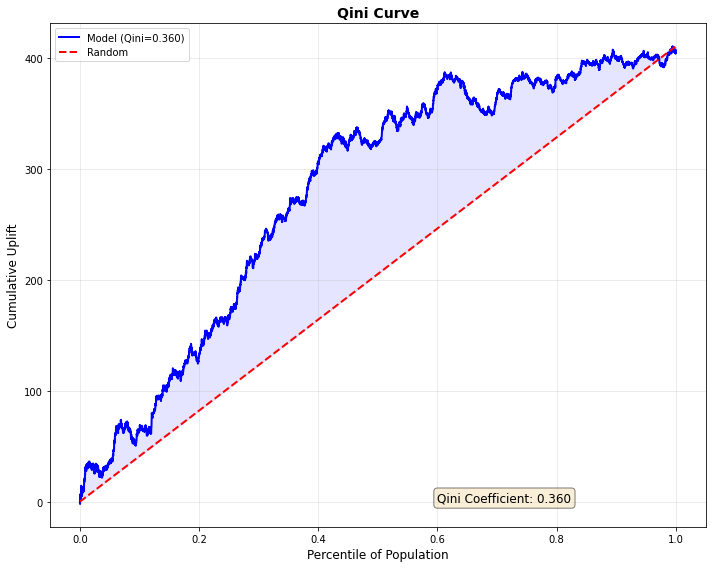

Qini 系数: 0.3600


In [145]:
# 方法1：完整计算（包含详细统计）
print("方法1：完整计算")
qini_coef, qini_df = calculate_qini_coefficient(
    result_df_all, 
    uplift_score_col='score_diff',
    treatment_col='treatment',
    target_col='y_t3',
    n_bins=10,
    plot=True
)
print(f"Qini 系数: {qini_coef:.4f}")

In [144]:
# 方法2：简化计算
print("\n方法2：简化计算")
qini_coef_simple, x, y = calculate_qini_simple(
    result_df_all,
    uplift_score_col='score_diff',
    treatment_col='treatment',
    target_col='y_t3',
    n_bins=100
)
print(f"Qini 系数（简化）: {qini_coef_simple:.4f}")


方法2：简化计算
Qini 系数（简化）: 0.3600


### 未抽样OOT评估

In [ ]:
df_oot_all=pd.read_parquet('/data/public_data/cpu4/tmp_yzq_repay_model_df_oot_all')

In [ ]:
# sklearn
#A 使用模型全量打分(读取的模型)
preds = model.predict_proba(df_oot_all[imp_features])[:,1]

In [ ]:
# 读取模型(原生模式)
import lightgbm as lgb
model = lgb.Booster(model_file='./repay_M2_v1_5.model')
print("✅ 模型加载成功")
## *读模型文件中的特征排序
imp_features=model.feature_name()
#A 使用模型全量打分(读取的模型)
preds = model.predict(df_oot_all[imp_features])

In [ ]:
# 计算KS值
fpr, tpr, thresholds = roc_curve(df_oot_all['y'], preds)
ks = np.max(tpr - fpr)
print("OOS KS Score:", ks)
# 计算AUC值
auc_score = roc_auc_score(df_oot_all['y'], preds)
print("OOS AUC Score:", auc_score)

In [ ]:
## 仅看复贷

In [ ]:
df_oot_reloan = df_oot_all[(df_oot_all.if_first_loan_order == 0)]

In [ ]:
# model 获取特征名和顺序
feature_names = model.booster_.feature_name()
# ## 缺失值填充（上线环境要求不含null）
# df_oot[imp_features].fillna(0, inplace=True)
## *读模型文件中的特征排序
imp_features=feature_names 
#A 使用模型全量打分(读取的模型)
preds = model.predict_proba(df_oot_reloan[imp_features])[:,1]

In [ ]:
# 计算KS值
fpr, tpr, thresholds = roc_curve(df_oot_reloan['y'], preds)
ks = np.max(tpr - fpr)
print("OOS KS Score:", ks)
# 计算AUC值
auc_score = roc_auc_score(df_oot_reloan['y'], preds)
print("OOS AUC Score:", auc_score)

### 排序性评估

In [ ]:
# 将预测结果与 user_id 对应起来
df = pd.DataFrame({'loan_account_id':df_oot_all['loan_account_id'],
                     'predict':preds,
                     'y':df_oot_all['y'],
                     'repay_amount_30d':df_oot_all['repay_amount_30d'],
                     'remain_amount':df_oot_all['remain_amount'],
                     'if_first_loan_order':df_oot_all['if_first_loan_order'],
                     'pt':df_oot_all['pt']
                    })
print(df.shape, df_oot_all.shape)
print(df['y'].mean(), df_oot_all['y'].mean())

In [ ]:
### 模型分分箱排序
df["predict_lv"] = pd.qcut(df["predict"],10)
result_df_lv = df.groupby(["predict_lv"],as_index=True)

In [ ]:
# df_min_max_bin = pd.DataFrame()#用来记录每个箱体的最大最小值
# df_min_max_bin["min_bin"] = result_df_lv.predict.min()
# df_min_max_bin["max_bin"] = result_df_lv.predict.max()
# df_min_max_bin.reset_index(inplace=True)
# # df_min_max_bin

In [ ]:
# result_lv = df.groupby(df['predict_lv']).agg({'loan_account_id':'count','y':'sum','repay_amount_30d':'sum','remain_amount':'sum'}).reset_index()
# result_lv

In [ ]:
# # 按 predict_lv 列进行倒序排序
# result_lv_sorted = result_lv.sort_values('predict_lv', ascending=False)
# print(result_lv_sorted)

In [ ]:
## 看首贷的
df = df[(df.if_first_loan_order == 1)]

In [ ]:
import pandas as pd
from IPython.display import display

# 基础计算（同上）
result_lv = df.groupby(df['predict_lv']).agg({'loan_account_id':'count','y':'sum','repay_amount_30d':'sum','remain_amount':'sum'}).reset_index()
result_lv = result_lv.sort_values('predict_lv', ascending=False).reset_index(drop=True)

total_customers = result_lv['loan_account_id'].sum()
total_bad = result_lv['y'].sum()
total_repay_amount_30d = result_lv['repay_amount_30d'].sum()
total_remain_amount = result_lv['remain_amount'].sum()
overall_bad_rate = total_bad / total_customers

# 计算指标
result_lv['精确率'] = result_lv['y'] / result_lv['loan_account_id']
result_lv['召回率'] = result_lv['y'] / total_bad
result_lv['Lift'] = result_lv['精确率'] / overall_bad_rate

result_lv['累计样本数'] = result_lv['loan_account_id'].cumsum()
result_lv['累计正样本数'] = result_lv['y'].cumsum()
result_lv['累计精确率'] = result_lv['累计正样本数'] / result_lv['累计样本数']
result_lv['累计召回率'] = result_lv['累计正样本数'] / total_bad
result_lv['累计Lift'] = result_lv['累计精确率'] / overall_bad_rate

# 创建显示用的DataFrame
display_df = result_lv[['predict_lv', 'loan_account_id', 'y','repay_amount_30d','remain_amount', '精确率', '召回率', 'Lift', '累计精确率', '累计召回率', '累计Lift']].copy()

# 格式化数值
def format_percentage(x):
    return f"{x*100:.1f}%" if pd.notnull(x) else "-"

def format_float(x):
    return f"{x:.1f}" if pd.notnull(x) else "-"

display_df['精确率'] = display_df['精确率'].apply(format_percentage)
display_df['召回率'] = display_df['召回率'].apply(lambda x: f"{x*100:.1f}%" if pd.notnull(x) else "-")
display_df['Lift'] = display_df['Lift'].apply(format_float)
display_df['累计精确率'] = display_df['累计精确率'].apply(format_percentage)
display_df['累计召回率'] = display_df['累计召回率'].apply(format_percentage)
display_df['累计Lift'] = display_df['累计Lift'].apply(format_float)

# 添加行号（从9到0）
display_df.index = range(len(display_df)-1, -1, -1)

# 添加合计行
total_display = pd.DataFrame({
    'predict_lv': ['合计'],
    'loan_account_id': [total_customers],
    'y': [total_bad],
    'repay_amount_30d':[total_repay_amount_30d],
    'remain_amount':[total_remain_amount],
    '精确率': [format_percentage(overall_bad_rate)],
    '召回率': ['100%'],
    'Lift': ['1.0'],
    '累计精确率': ['-'],
    '累计召回率': ['-'],
    '累计Lift': ['-']
}, index=['合计'])

# 合并显示
final_display = pd.concat([display_df, total_display])

# 设置列名中文显示
final_display.columns = ['predict_lv', 'loan_account_id', 'y','M2催回总金额','待还总金额', '精确率', '召回率', 'Lift', '累计精确率', '累计召回率', '累计Lift']

print("模型分析报告")
print("=" * 90)
display(final_display)

In [ ]:
# # 首先查看DataFrame的实际列数和列名
# print("DataFrame的列数:", len(final_display.columns))
# print("DataFrame的列名:", list(final_display.columns))
# print("尝试设置的列数:", 11)

# # 查看前几行数据了解结构
# print("\nDataFrame前几行:")
# print(final_display.head())

### bin内auc

In [ ]:
#bin内auc，valid_data为验证数据集，m6_score为主模型分，pred为新模型分
label='y'
bins=pd.qcut(df['predict'],10,retbins=True)[1]
res_auc=[]

In [ ]:
for i in range(len(bins)-1):
    tmp=df.query('predict>%s and predict<=%s'%(bins[i],bins[i+1]))
    auc1=roc_auc_score(tmp[label],tmp['predict'])
    res_auc.append([bins[i],tmp.shape[0],auc1])
df_auc=pd.DataFrame(res_auc)
df_auc.columns=['bin','count','auc']
df_auc

### 稳定性评估

In [ ]:
# df['month']=df['pt'].apply(lambda x:x[:6])
df['month'] = (df['pt'] // 100).astype(str)  # 如果pt格式是YYYYMMDD，除以100得到YYYYMM
# df_sample['month'] = (df_sample['pt'] // 100).astype(str)
# df_oot['month'] = (df_oot['pt'] // 100).astype(str)

In [ ]:
# 基本透视表
pivot_result = df.pivot_table(
    index='predict_lv',      # 行索引
    columns='month',         # 列索引
    values='loan_account_id', # 要聚合的值
    aggfunc='count',         # 聚合函数
    fill_value=0             # 填充空值
)
print(pivot_result)

#### AUC by月

In [ ]:
# 假设你的数据中有月份字段，比如'month'
# 如果没有，需要先创建月份字段

# 按月份分组计算AUC和KS
months = df['month'].unique()
monthly_metrics = []

for month in sorted(months):
    month_data = df[df['month'] == month]
    
    # 计算该月的KS值
    fpr, tpr, thresholds = roc_curve(month_data['y'], month_data['predict'])
    ks = np.max(tpr - fpr)
    
    # 计算该月的AUC值
    auc_score = roc_auc_score(month_data['y'], month_data['predict'])
    monthly_metrics.append({
        'month': month,
        'auc': auc_score,
        'ks': ks,
        'sample_size': len(month_data)
    })
    print(f"Month {month}: AUC = {auc_score:.4f}, KS = {ks:.4f}, 样本量 = {len(month_data)}")

# 转换为DataFrame便于分析
metrics_df = pd.DataFrame(monthly_metrics)
print("\n月度指标汇总:")
print(metrics_df)

#### 效果by月

In [ ]:
import pandas as pd
from IPython.display import display

def analyze_model_by_month(df, month_col='month'):
    """
    按月份分析模型表现
    
    Parameters:
    df: 包含预测结果和月份的数据
    month_col: 月份字段名
    """
    
    monthly_results = {}
    months = sorted(df[month_col].unique())
    
    for month in months:
        print(f"\n{'='*80}")
        print(f"月份: {month}")
        print(f"{'='*80}")
        
        # 筛选当月数据
        month_df = df[df[month_col] == month]
        
        # 基础计算
        result_lv = month_df.groupby(month_df['predict_lv']).agg({
            'loan_account_id': 'count',
            'y': 'sum',
            'repay_amount_30d': 'sum',
            'remain_amount': 'sum'
        }).reset_index()
        
        result_lv = result_lv.sort_values('predict_lv', ascending=False).reset_index(drop=True)

        total_customers = result_lv['loan_account_id'].sum()
        total_bad = result_lv['y'].sum()
        total_repay_amount_30d = result_lv['repay_amount_30d'].sum()
        total_remain_amount = result_lv['remain_amount'].sum()
        overall_bad_rate = total_bad / total_customers if total_customers > 0 else 0

        # 计算指标
        result_lv['精确率'] = result_lv['y'] / result_lv['loan_account_id']
        result_lv['召回率'] = result_lv['y'] / total_bad if total_bad > 0 else 0
        result_lv['Lift'] = result_lv['精确率'] / overall_bad_rate if overall_bad_rate > 0 else 0

        result_lv['累计样本数'] = result_lv['loan_account_id'].cumsum()
        result_lv['累计正样本数'] = result_lv['y'].cumsum()
        result_lv['累计精确率'] = result_lv['累计正样本数'] / result_lv['累计样本数']
        result_lv['累计召回率'] = result_lv['累计正样本数'] / total_bad if total_bad > 0 else 0
        result_lv['累计Lift'] = result_lv['累计精确率'] / overall_bad_rate if overall_bad_rate > 0 else 0

        # 创建显示用的DataFrame
        display_df = result_lv[[
            'predict_lv', 'loan_account_id', 'y', 'repay_amount_30d', 'remain_amount', 
            '精确率', '召回率', 'Lift', '累计精确率', '累计召回率', '累计Lift'
        ]].copy()

        # 格式化数值
        def format_percentage(x):
            return f"{x*100:.1f}%" if pd.notnull(x) and not pd.isna(x) else "-"

        def format_float(x):
            return f"{x:.2f}" if pd.notnull(x) and not pd.isna(x) else "-"

        display_df['精确率'] = display_df['精确率'].apply(format_percentage)
        display_df['召回率'] = display_df['召回率'].apply(format_percentage)
        display_df['Lift'] = display_df['Lift'].apply(format_float)
        display_df['累计精确率'] = display_df['累计精确率'].apply(format_percentage)
        display_df['累计召回率'] = display_df['累计召回率'].apply(format_percentage)
        display_df['累计Lift'] = display_df['累计Lift'].apply(format_float)

        # 添加行号（从高到低）
        display_df.index = range(len(display_df)-1, -1, -1)

        # 添加合计行
        total_display = pd.DataFrame({
            'predict_lv': ['合计'],
            'loan_account_id': [total_customers],
            'y': [total_bad],
            'repay_amount_30d': [total_repay_amount_30d],
            'remain_amount': [total_remain_amount],
            '精确率': [format_percentage(overall_bad_rate)],
            '召回率': ['100%'],
            'Lift': ['1.0'],
            '累计精确率': ['-'],
            '累计召回率': ['-'],
            '累计Lift': ['-']
        }, index=['合计'])

        # 合并显示
        final_display = pd.concat([display_df, total_display])

        # 设置列名中文显示
        final_display.columns = [
            '预测分档', '样本数', '坏样本数', 'M2催回总金额', '待还总金额', 
            '精确率', '召回率', 'Lift', '累计精确率', '累计召回率', '累计Lift'
        ]

        print(f"月份 {month} - 模型分析报告")
        print(f"总样本数: {total_customers:,} | 坏样本数: {total_bad:,} | 整体坏账率: {overall_bad_rate:.2%}")
        display(final_display)
        
        # 存储结果用于汇总分析
        monthly_results[month] = {
            'total_customers': total_customers,
            'total_bad': total_bad,
            'overall_bad_rate': overall_bad_rate,
            'total_repay_amount': total_repay_amount_30d,
            'total_remain_amount': total_remain_amount,
            'result_table': final_display
        }
    
    return monthly_results

def create_monthly_summary(monthly_results):
    """
    创建月度汇总报告
    """
    summary_data = []
    
    for month, results in monthly_results.items():
        summary_data.append({
            '月份': month,
            '总样本数': results['total_customers'],
            '坏样本数': results['total_bad'],
            '整体坏账率': f"{results['overall_bad_rate']:.2%}",
            'M2催回总金额': results['total_repay_amount'],
            '待还总金额': results['total_remain_amount'],
            '样本占比': f"{(results['total_customers'] / sum(r['total_customers'] for r in monthly_results.values())):.1%}"
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    print(f"\n{'='*80}")
    print("月度表现汇总")
    print(f"{'='*80}")
    display(summary_df)
    
    return summary_df

# 使用示例
if __name__ == "__main__":
    # 确保数据中包含月份字段
    # 如果还没有月份字段，需要先创建
    # df['month'] = df['date_column'].dt.to_period('M')
    
    # 执行月度分析
    monthly_results = analyze_model_by_month(df, 'month')
    
    # 生成汇总报告
    summary_df = create_monthly_summary(monthly_results)


## 单变量分析

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def feature_plt(data, col, target, fillna=-99999, bins=10):
    df = data[[col, target]].copy()
    if fillna is not None:
        df[col] = df[col].fillna(fillna)
    if type(bins) == list:
        df[col] = pd.cut(df[col], bins, labels=labels_name(bins), include_lowest=True)
    else:
        np.arange(1 / 20, 1, 1 / 20)
        
    cut_list = list(np.unique(df[col].quantile(np.arange(1 / bins, 1, 1 / bins))))  # 分位切分
    cut_list = list(np.unique([-np.inf, fillna] + cut_list + [np.inf]))
    labels = ['Missing'] + ['<=' + str(round(i, 5)) for i in cut_list[2:-1]] + ['>' + str(cut_list[-2])]
    print(labels)
    df[col] = pd.cut(df[col], cut_list, labels=labels)
        
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))
    ax2 = ax1.twinx()
    sns.countplot(x=col, data=df, color='g', ax=ax1, alpha=0.4, label='cnt')
    sns.lineplot(x=col, y=target, data=df, ci=None, ax=ax2, marker='o', label=col, legend=False)
    fig.legend(loc=1, bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)

In [ ]:
imp_features = [
# V2
# 'PHI_SMS_COMPETITORS_PATTERN_V5_1___features___patternCategoryUnknownV10Last90DLastHoursInterval'
# ,'PHI_ORDER_BEHAVIOR___recentOneVO___daysSinceLastCompleted'
# ,'PHI_ORDER_BEHAVIOR___recentTwoVO___daysTermOverdueStd'
# ,'PHI_BEHAVIOR_ORDER_AND_INSTALLMENT___behaviorOrderAndInstallmentAllDays___aheadCompleteBillDaysRatio___min'
# ,'PHI_WOE_5CV_APP_V3___features___mob1_max7_cnt_woe_avg_allInstalledShardingLast360D'
# ,'PHI_ORDER_INFO_FOR_MULTI_LOAN___withInOneOrder___totalBadDebtAmount'
# ,'PHI_APP_CATEGORY_DELTA_GAP_V1___features___categoryDeltaGap_noSys_ALL_tools_DELETE_MIN_GAP'
# ,'PHI_SMS_KEYWORD_WOE_V2___features___type_1_p3_avg_mob1_max7_cnt_woeLast15D'
# ,'PHI_REPAYMENT_PAY_DAY___last60DStat___maxSingleDayRepayAmountToNoRepayRatio'
# ,'PHI_BATCH_APP___loanAppV1AfterLoan___loanAppRatio'
# ,'PHI_ORDER_TERM___statAll___maxConsecutiveCompletedAheadTermRatio'
# ,'PHI_ORDER_INFO_FOR_MULTI_LOAN___withInThreeFuture___notDueAndUnCompletedAmountOverIncomeRatio'
# ,'PHI_SMS_KEYWORD_WOE_V2___features___type_1_p4_unique_avg_mob1_max7_cnt_woeLast30D'
# ,'INSTALMEN_RESOLVE_AMOUNT_ON_T1___outStanding_mean_30DgapOutstanding_gap1_recent6M_gap'
# ,'PHI_WOE_5CV_APP_V3___features___mob2_max7_cnt_woe_avg_allInstalledShardingLast90D'
# ,'PHI_MULTI_LOAN_IN_LOAN_ORDER___all___multiLoanCreditUsageRatioMathCount___avg'
# ,'PHI_SMS_KEYWORD_WOE_V2___features___type_all_p2_avg_d1_cnt_woeLast90D'
# ,'PHI_REPAYMENT_PAY_DAY___last60DStat___diffAvgDayBetweenCloseAdvanceRepayAndRepay'
# ,'PHI_WOE_5CV_APP_V3___features___d15_cnt_woe_sum_allInstalledShardingLast30D'
# ,'PHI_REPAYMENT_PRESSURE___preFeatureVO___inLoanOrder1M___creditResultVO___ratioDueAmountAndCreditPrincipal'
    
# V3
# 'PHI_SMS_COMPETITORS_PATTERN_V5_1___features___patternCategoryUnknownV10Last90DLastHoursInterval'
# ,'PHI_ORDER_BEHAVIOR___recentOneVO___daysSinceLastCompleted'
# ,'PHI_BEHAVIOR_ORDER_AND_INSTALLMENT___behaviorOrderAndInstallmentAllDays___aheadCompleteBillDaysRatio___min'
# ,'PHI_ORDER_BEHAVIOR___recentTwoVO___daysTermOverdueStd'
# ,'PHI_WOE_5CV_APP_V3___features___mob1_max7_cnt_woe_avg_allInstalledShardingLast360D'
# ,'PHI_ORDER_INFO_FOR_MULTI_LOAN___withInOneOrder___totalBadDebtAmount'
# ,'PHI_APP_CATEGORY_DELTA_GAP_V1___features___categoryDeltaGap_noSys_ALL_tools_DELETE_MIN_GAP'
# ,'PHI_BATCH_APP___loanAppV1AfterLoan___loanAppRatio'
# ,'PHI_REPAYMENT_PAY_DAY___last60DStat___maxSingleDayRepayAmountToNoRepayRatio'
# ,'PHI_ORDER_INFO_FOR_MULTI_LOAN___withInThreeFuture___notDueAndUnCompletedAmountOverIncomeRatio'
# ,'PHI_ORDER_TERM___statAll___maxConsecutiveCompletedAheadTermRatio'
# ,'PHI_REPAYMENT_PRESSURE___preFeatureVO___inLoanOrder1M___creditResultVO___ratioDueAmountAndCreditPrincipal'
# ,'PHI_SMS_KEYWORD_WOE_V2___features___type_1_p4_unique_avg_mob1_max7_cnt_woeLast30D'
# ,'PHI_SMS_KEYWORD_WOE_V2___features___type_1_p3_avg_mob1_max7_cnt_woeLast15D'
# ,'PHI_ORDER_INFO_FOR_MULTI_LOAN___lastCompletedOverUnCompletedAmountRatio'
# ,'REVOLVING_LOAN_FEATURE___recentTermAndNotDueAmountDiffDay59dRatio'
# ,'PHI_WOE_5CV_APP_V3___features___mob2_max7_cnt_woe_avg_allInstalledShardingLast90D'
# ,'PHI_REPAYMENT_PAY_DAY___last60DStat___diffAvgDayBetweenCloseAdvanceRepayAndRepay'
# ,'PHI_SMS_KEYWORD_WOE_V2___features___type_all_p3_unique_sum_d1_cnt_woeLast30D'
# ,'PHI_ORDER_BEHAVIOR___statVO180dFixed___avgDaysSinceLastCompleted'
    
# V4
# 'PHI_BEHAVIOR_ORDER_AND_INSTALLMENT___behaviorOrderAndInstallmentAllDays___aheadCompleteBillDaysRatio___min'
# ,'PHI_SMS_KEY_WORD_TIME_DIFF_V1___features___keywordTimeDiffMinV1Latest1000F1069'
# ,'PHI_SMS_KEYWORD_WOE_V2___features___type_1_p3_avg_mob1_max7_cnt_woeLast15D'
# ,'PHI_APP_CATEGORY_DELTA_GAP_V1___features___categoryDeltaGap_noSys_ALL_tools_DELETE_MIN_GAP'
# ,'PHI_ORDER_INFO_FOR_MULTI_LOAN___withInOneOrder___totalBadDebtAmount'
# ,'PHI_SMS_KEYWORD_WOE_V2___features___type_all_p3_unique_sum_d1_cnt_woeLast30D'
# ,'PHI_REPAYMENT_PAY_DAY___last60DStat___maxSingleDayRepayAmountToNoRepayRatio'
# ,'PHI_SMS_KEYWORD_WOE_V2___features___type_1_p4_unique_avg_mob1_max7_cnt_woeLast30D'
# ,'PHI_ORDER_TERM___statAll___maxConsecutiveCompletedAheadTermRatio'
# ,'PHI_MULTI_LOAN_IN_LOAN_ORDER___all___multiLoanCreditUsageRatioMathCount___avg'
# ,'PHI_SMS_KEYWORD_WOE_V2___features___type_1_p4_avg_d1_cnt_woeLast30D'
# ,'PHI_APP_CATEGORY_DELTA_GAP_V1___features___categoryDeltaGap_noSys_WIN_7_30D_gerendaikuan_INIT_INSTALL_MIN_GAP'
# ,'PHI_ORDER_INFO_FOR_MULTI_LOAN___withInThreeFuture___notDueAndUnCompletedAmountOverIncomeRatio'
# ,'PHI_REPAYMENT_PAY_DAY___last60DStat___diffAvgDayBetweenCloseAdvanceRepayAndRepay'
# ,'PHI_SMS_KEYWORD_WOE_V2___features___type_1_p3_unique_std_d7_cnt_woeLast15D'
# ,'PHI_APP_CATEGORY_WITH_COMPARE_APP_COUNT_HIGH_LOW_RATES_V1___features___categoryStatCntAfterRegisterV22NoSysGeRenDaiKuanInstalledDown1Million'
# ,'REVOLVING_LOAN_FEATURE___recentTermAndNotDueAmountDiffDay59dRatio'
# ,'PHI_ORDER_INFO_FOR_MULTI_LOAN___lastCompletedOverUnCompletedAmountRatio'
# ,'PHI_SMS_KEY_WORD_TIME_DIFF_V1___features___keywordTimeDiffMinV1Latest1000F703'
# ,'INSTALMEN_RESOLVE_AMOUNT_ON_T1___outStanding_mean_30DgapOutstanding_gap1_recent6M_gap'
    
# V5
'PHI_APP_CATEGORY_DELTA_GAP_V1___features___categoryDeltaGap_noSys_ALL_tools_DELETE_MIN_GAP'
,'PHI_BEHAVIOR_ORDER_AND_INSTALLMENT___behaviorOrderAndInstallmentAllDays___aheadCompleteBillDaysRatio___min'
,'PHI_ORDER_INFO_FOR_MULTI_LOAN___withInOneOrder___totalBadDebtAmount'
,'PHI_APP_CATEGORY_DELTA_GAP_V1___features___categoryDeltaGap_noSys_WIN_7_30D_gerendaikuan_INIT_INSTALL_MIN_GAP'
,'PHI_ORDER_TERM___statAll___maxConsecutiveCompletedAheadTermRatio'
,'PHI_APP_CATEGORY_WITH_COMPARE_APP_COUNT_HIGH_LOW_RATES_V1___features___categoryStatCntAfterRegisterV22NoSysGeRenDaiKuanInstalledDown1Million'
,'PHI_ORDER_INFO_FOR_MULTI_LOAN___withInThreeFuture___notDueAndUnCompletedAmountOverIncomeRatio'
,'PHI_REPAYMENT_PAY_DAY___last60DStat___diffAvgDayBetweenCloseAdvanceRepayAndRepay'
,'PHI_REPAYMENT_PAY_DAY___last60DStat___maxSingleDayRepayAmountToNoRepayRatio'
,'PHI_MULTI_LOAN_IN_LOAN_ORDER___all___multiLoanCreditUsageRatioMathCount___avg'
,'PHI_APP_PACKAGE_SUBSTRING_EMBEDDING_V1___features___packageSubstringEmbeddingSumV1NoSysInstallLast7DF261'
,'PHI_REPAYMENT_PAY_DAY___last120DStat___maxSingleDayCloseRepayAmountToNoRepayRatio'
,'REVOLVING_LOAN_FEATURE___recentTermAndNotDueAmountDiffDay59dRatio'
,'PHI_ORDER_INFO_FOR_MULTI_LOAN___lastCompletedOverUnCompletedAmountRatio'
,'PHI_REPAYMENT_PRESSURE___preFeatureVO___historyCompletedOrder6M___baseDataVO___oDueAmount'
,'INSTALMEN_RESOLVE_AMOUNT_ON_T1___outStanding_mean_30DgapOutstanding_gap1_recent6M_gap'
,'PHI_APP_CATEGORY_DELTA_GAP_V1___features___categoryDeltaGap_noSys_ALL_communication_DELETE_MIN_GAP'
,'PHI_APP_CATEGORY_DELTA_GAP_V1___features___categoryDeltaGap_noSys_ALL_liulanqiyusousuoyinqing_DELETE_MAX_GAP'
,'PHI_REPAYMENT_PRESSURE___secondPartPreFeatureVO___pre3MInLoanResultVO___creditResultVO___maxRatioCompletedAmountAndCreditPrincipal'
,'BORROW_TO_PAY_AMOUNT_RATIO___Borrow_To_Pay_mean_Amount_Ratio_OrderPrincipal_Recent1OrderRemainDuePrincipal_Past_180Days'

]

### Train

In [ ]:
plot_list = imp_features
cat_list = []

count = 0
for col in plot_list:
    if count > 20:
        break
    dff = feature_plt(df_sample.reset_index(), col, 'y', fillna=-999, bins=10)
    dff
    count += 1

### OOT

In [ ]:
plot_list = imp_features
cat_list = []

count = 0
for col in plot_list:
    if count > 20:
        break
    dff = feature_plt(df_oot.reset_index(), col, 'y', fillna=-999, bins=10)
    dff
    count += 1

In [ ]:
negative_records = df_oot_all[df_oot_all['PHI_ORDER_BEHAVIOR___recentOneVO___daysSinceLastCompleted'] < 0]

print(f"找到 {len(negative_records)} 条负值记录")
print(negative_records)

## 特征PSI

### 空值对比

In [ ]:
# # 读取模型
model = joblib.load('./repay_M2_v5.pkl')

In [ ]:
# model 获取特征名和顺序
feature_names = model.booster_.feature_name()
## *读模型文件中的特征排序
imp_features=feature_names 

In [ ]:
base_data = df_sample[imp_features]
current_data = df_oot[imp_features]
# 计算空值占比
base_nan_ratio = base_data.isna().mean()
current_nan_ratio = current_data.isna().mean()

In [ ]:
base_nan_ratio

In [ ]:
base_nan_ratio.to_csv('./df_sample_features_nan_ratio_v4.csv', header=True, index=True, encoding='utf-8-sig')

In [ ]:
current_nan_ratio.to_csv('./df_oot_features_nan_ratio_v4.csv', header=True, index=True, encoding='utf-8-sig')

### PSI统计_train_oot

In [ ]:
import pandas as pd
import numpy as np

def calculate_psi(expected, actual, buckets=10):
    """计算PSI值 - 修复版本"""
    # 处理空值
    expected = expected.dropna()
    actual = actual.dropna()
    
    if len(expected) == 0 or len(actual) == 0:
        return np.nan
    
    # 生成分箱边界，确保唯一性
    breakpoints = np.unique(np.percentile(expected, np.linspace(0, 100, buckets + 1)))
    
    # 如果分箱数太少，使用等宽分箱
    if len(breakpoints) < 2:
        breakpoints = np.linspace(expected.min(), expected.max(), buckets + 1)
    
    # 计算百分比
    expected_percents = np.histogram(expected, breakpoints)[0] / len(expected)
    actual_percents = np.histogram(actual, breakpoints)[0] / len(actual)
    
    # 处理0值
    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    actual_percents = np.where(actual_percents == 0, 0.0001, actual_percents)
    
    # 计算PSI
    psi = np.sum((expected_percents - actual_percents) * np.log(expected_percents / actual_percents))
    return psi

def feature_psi_comparison(df_sample, df_oot, features=None):
    """特征PSI对比"""
    if features is None:
        # 只选择数值型特征
        features = df_sample.select_dtypes(include=[np.number]).columns
    
    common_features = set(features) & set(df_oot.columns)
    psi_results = []
    
    for feature in common_features:
        try:
            psi_val = calculate_psi(df_sample[feature], df_oot[feature])
            psi_results.append({
                'feature': feature,
                'psi': psi_val,
                'sample_size': len(df_sample[feature].dropna()),
                'oot_size': len(df_oot[feature].dropna())
            })
        except Exception as e:
            print(f"计算特征 {feature} 的PSI时出错: {e}")
            continue
    
    psi_df = pd.DataFrame(psi_results)
    return psi_df.sort_values('psi', ascending=False)

In [ ]:
# 使用示例
psi_results = feature_psi_comparison(df_sample[imp_features], df_oot[imp_features])

# 显示结果
print("PSI结果排序：")
print(psi_results.head(10))

In [ ]:
psi_results.to_csv('./features_psi_v5.csv', header=True, index=False, encoding='utf-8-sig')

In [ ]:
# # 稳定性判断
# def psi_stability_judgment(psi_df):
#     """PSI稳定性判断"""
#     conditions = [
#         psi_df['psi'] < 0.1,
#         (psi_df['psi'] >= 0.1) & (psi_df['psi'] < 0.25),
#         psi_df['psi'] >= 0.25
#     ]
#     choices = ['稳定', '略有波动', '显著波动']
#     psi_df['stability'] = np.select(conditions, choices, default='未知')
#     return psi_df
# psi_results = psi_stability_judgment(psi_results)
# print("\n稳定性分布：")
# print(psi_results['stability'].value_counts())

### PSI统计_oot_by月

In [ ]:
## V3
## pt：特征分区
df_oot1 = df_oot.loc[
    ((df_oot.pt >= 20250601) & (df_oot.pt <= 20250630)) ,
    :]
df_oot2 = df_oot.loc[
    ((df_oot.pt >= 20250701) & (df_oot.pt <= 20250731)) ,
    :]
df_oot3 = df_oot.loc[
    ((df_oot.pt >= 20250801) & (df_oot.pt <= 20250831)) ,
    :]
df_oot4 = df_oot.loc[
    ((df_oot.pt >= 20250901) & (df_oot.pt <= 20250930)) ,
    :]

In [ ]:
# 使用示例
psi_results_1_2 = feature_psi_comparison(df_oot1[features], df_oot2[features])
psi_results_1_2.to_csv('./features_psi_oot_1_2_v4.csv', header=True, index=False, encoding='utf-8-sig')

In [ ]:
# 使用示例
psi_results_2_3 = feature_psi_comparison(df_oot2[features], df_oot3[features])
psi_results_2_3.to_csv('./features_psi_oot_2_3_v4.csv', header=True, index=False, encoding='utf-8-sig')

In [ ]:
# 使用示例
psi_results_3_4 = feature_psi_comparison(df_oot3[features], df_oot4[features])
psi_results_3_4.to_csv('./features_psi_oot_3_4_v4.csv', header=True, index=False, encoding='utf-8-sig')

In [ ]:
# 使用示例
psi_results_1_4 = feature_psi_comparison(df_oot1[features], df_oot4[features])
psi_results_1_4.to_csv('./features_psi_oot_1_4_v4.csv', header=True, index=False, encoding='utf-8-sig')

## 模型分PSI

In [ ]:
## Train 打分 用于模型psi

In [ ]:
# model 获取特征名和顺序
feature_names = model.booster_.feature_name()
# ## 缺失值填充（上线环境要求不含null）
# df_oot[imp_features].fillna(0, inplace=True)
## *读模型文件中的特征排序
imp_features=feature_names 
#A 使用模型全量打分(读取的模型)
preds = model.predict_proba(df_sample[imp_features])[:,1]

In [ ]:
# 计算KS值
fpr, tpr, thresholds = roc_curve(df_sample['y'], preds)
ks = np.max(tpr - fpr)
print("OOT KS Score:", ks)
# 计算AUC值
auc_score = roc_auc_score(df_sample['y'], preds)
print("OOT AUC Score:", auc_score)

In [ ]:
# 将预测结果与 user_id 对应起来
df_sample_score = pd.DataFrame({'loan_account_id':df_sample['loan_account_id'],
                     'predict':preds,
                     'y':df_sample['y'],
                     'repay_amount_30d':df_sample['repay_amount_30d'],
                     'remain_amount':df_sample['remain_amount']
                    })
print(df_sample_score.shape, df_sample.shape)
print(df_sample_score['y'].mean(), df_sample['y'].mean())

In [ ]:
def calculate_model_score_psi(df_sample, df_oot, score_column='predict'):
    """
    计算模型分的PSI
    """
    # 提取模型分
    sample_scores = df_sample[score_column].dropna()
    oot_scores = df_oot[score_column].dropna()
    
    print(f"样本集大小: {len(sample_scores)}")
    print(f"OOT集大小: {len(oot_scores)}")
    print(f"样本集模型分统计: 均值={sample_scores.mean():.4f}, 标准差={sample_scores.std():.4f}")
    print(f"OOT集模型分统计: 均值={oot_scores.mean():.4f}, 标准差={oot_scores.std():.4f}")
    
    # 计算PSI
    psi = calculate_psi(sample_scores, oot_scores)
    
    # 稳定性判断
    if psi < 0.1:
        stability = "稳定"
    elif psi < 0.25:
        stability = "略有波动" 
    else:
        stability = "显著波动"
    
    print(f"\n模型分PSI: {psi:.6f}")
    print(f"稳定性: {stability}")
    return psi, stability

In [ ]:
# V5
psi_score, stability = calculate_model_score_psi(df_sample_score, df_oot_score, 'predict')

In [ ]:
# V4
psi_score, stability = calculate_model_score_psi(df_sample_score, df_oot_score, 'predict')

## 模型对比

In [ ]:
## 取相同样本下的老模型打分
df_ft_ios = pd.read_parquet("/data/etl_data/phi_etl_file/20251114/")
df_ft_ios = df_ft_ios.drop(['userId','orderId','traceId'],axis=1)
df_ft_ios = df_ft_ios.rename(columns={'traceId':'first_trace_id',
        'modelId_200000420':'reloan_collection_model_v2_fix',
        'modelId_200000200':'phi_C_collect_model_filter_feas_20240805_lgb_v2',
        'modelId_200000199':'phi_C_collect_model_20240805_lgb_v2',
                                     })
df_ft_ios.shape

In [ ]:
df_ft_ios.dtypes

In [ ]:
current_datetime = datetime.datetime.now()
print("开始:", current_datetime)
object_cols = df_ft_ios.select_dtypes(include=['object']).columns
if len(object_cols) > 0:
    df_ft_ios[object_cols] = df_ft_ios[object_cols].apply(pd.to_numeric, errors='coerce')
current_datetime = datetime.datetime.now()
print("结束:", current_datetime)

In [ ]:
df_ft_ios['pt'] = pd.to_datetime(df_ft_ios['time_stamp'], unit='ms').dt.strftime('%Y%m%d').astype(int)  ## 8位数字类型
##.dt.date ## 10位日期类型
# print(dff['pt'])

In [ ]:
df_ft_ios

In [ ]:
dff =pd.merge(df_oot_all,df_ft_ios,## on=['loanAccountId','time_stamp']
              left_on=['loanAccountId', 'time_stamp'],
              right_on=['loanAccountId', 'time_stamp']
              ,how='left')

In [ ]:
dff['y'].value_counts()

In [ ]:
df_oot_all['y'].value_counts()

In [ ]:
# 合并后直接去除完全重复的行
dff_clean = dff.drop_duplicates()

print(f"去重前行数: {len(dff)}")
print(f"去重后行数: {len(dff_clean)}")
print(f"去除重复行数: {len(dff) - len(dff_clean)}")

In [ ]:
## 发现每条记录都有一行模型分为空值的副本，需要去除

In [ ]:
dff_unique = dff[dff['reloan_collection_model_v2_fix'].notna()]

In [ ]:
dff_unique['y'].value_counts()

In [ ]:
# dff_unique.to_parquet('/data/public_data/cpu4/tmp_yzq_repay_model_yangben_oos',compression='gzip',index=False)

In [ ]:
dff_unique = pd.read_parquet("/data/public_data/cpu4/tmp_yzq_repay_model_yangben_oos")

In [ ]:
dff_unique = dff_unique[(dff_unique.if_first_loan_order == 0)]

In [ ]:
# 计算KS值
fpr, tpr, thresholds = roc_curve(dff_unique['y'], dff_unique['reloan_collection_model_v2_fix'])
ks = np.max(tpr - fpr)
print("OOS KS Score:", ks)
# 计算AUC值
auc_score = roc_auc_score(dff_unique['y'], dff_unique['reloan_collection_model_v2_fix'])
print("OOS AUC Score:", auc_score)

### 排序性评估

In [ ]:
### 模型分分箱排序
dff_unique["predict_lv"] = pd.qcut(dff_unique["reloan_collection_model_v2_fix"],10)
result_dff_lv = dff_unique.groupby(["predict_lv"],as_index=True)

In [ ]:
# df_min_max_bin = pd.DataFrame()#用来记录每个箱体的最大最小值
# df_min_max_bin["min_bin"] = result_dff_lv.reloan_collection_model_v2_fix.min()
# df_min_max_bin["max_bin"] = result_dff_lv.reloan_collection_model_v2_fix.max()
# df_min_max_bin.reset_index(inplace=True)
# # df_min_max_bin

In [ ]:
# result_lv_old = dff_unique.groupby(dff_unique['predict_lv']).agg({'loan_account_id':'count','y':'sum','repay_amount_30d':'sum','remain_amount':'sum'}).reset_index()
# result_lv_old

In [ ]:
# # 按 predict_lv 列进行倒序排序
# result_lv_sorted_old = result_lv_old.sort_values('predict_lv', ascending=False)
# print(result_lv_sorted_old)

In [ ]:
## 看复贷的
dff = dff[(dff.if_first_loan_order == 0)]

In [ ]:
import pandas as pd
from IPython.display import display

# 基础计算（同上）
result_lv = dff.groupby(dff['predict_lv']).agg({'loan_account_id':'count','y':'sum','repay_amount_30d':'sum','remain_amount':'sum'}).reset_index()
result_lv = result_lv.sort_values('predict_lv', ascending=False).reset_index(drop=True)

total_customers = result_lv['loan_account_id'].sum()
total_bad = result_lv['y'].sum()
total_repay_amount_30d = result_lv['repay_amount_30d'].sum()
total_remain_amount = result_lv['remain_amount'].sum()
overall_bad_rate = total_bad / total_customers

# 计算指标
result_lv['精确率'] = result_lv['y'] / result_lv['loan_account_id']
result_lv['召回率'] = result_lv['y'] / total_bad
result_lv['Lift'] = result_lv['精确率'] / overall_bad_rate

result_lv['累计样本数'] = result_lv['loan_account_id'].cumsum()
result_lv['累计正样本数'] = result_lv['y'].cumsum()
result_lv['累计精确率'] = result_lv['累计正样本数'] / result_lv['累计样本数']
result_lv['累计召回率'] = result_lv['累计正样本数'] / total_bad
result_lv['累计Lift'] = result_lv['累计精确率'] / overall_bad_rate

# 创建显示用的DataFrame
display_df = result_lv[['predict_lv', 'loan_account_id', 'y','repay_amount_30d','remain_amount', '精确率', '召回率', 'Lift', '累计精确率', '累计召回率', '累计Lift']].copy()

# 格式化数值
def format_percentage(x):
    return f"{x*100:.1f}%" if pd.notnull(x) else "-"

def format_float(x):
    return f"{x:.1f}" if pd.notnull(x) else "-"

display_df['精确率'] = display_df['精确率'].apply(format_percentage)
display_df['召回率'] = display_df['召回率'].apply(lambda x: f"{x*100:.1f}%" if pd.notnull(x) else "-")
display_df['Lift'] = display_df['Lift'].apply(format_float)
display_df['累计精确率'] = display_df['累计精确率'].apply(format_percentage)
display_df['累计召回率'] = display_df['累计召回率'].apply(format_percentage)
display_df['累计Lift'] = display_df['累计Lift'].apply(format_float)

# 添加行号（从9到0）
display_df.index = range(len(display_df)-1, -1, -1)

# 添加合计行
total_display = pd.DataFrame({
    'predict_lv': ['合计'],
    'loan_account_id': [total_customers],
    'y': [total_bad],
    'repay_amount_30d':[total_repay_amount_30d],
    'remain_amount':[total_remain_amount],
    '精确率': [format_percentage(overall_bad_rate)],
    '召回率': ['100%'],
    'Lift': ['1.0'],
    '累计精确率': ['-'],
    '累计召回率': ['-'],
    '累计Lift': ['-']
}, index=['合计'])

# 合并显示
final_display = pd.concat([display_df, total_display])

# 设置列名中文显示
final_display.columns = ['predict_lv', 'loan_account_id', 'y','M2催回总金额','待还总金额', '精确率', '召回率', 'Lift', '累计精确率', '累计召回率', '累计Lift']

print("模型分析报告")
print("=" * 90)
display(final_display)

## 模型交叉对比

In [ ]:
# pd.set_option('display.max_columns', 30)  # 设置足够显示所有列
# pd.set_option('display.width', 1000)      # 设置足够的宽度

In [ ]:
# #模型交叉
# def df_cross(data,bin1,bin2,label):
#     res1=pd.crosstab(data[bin1],data[bin2],margins=True)
#     tmp=data.groupby([bin1,bin2])[label].sum()/data.groupby([bin1,bin2]).size()
#     tmp=tmp.reset_index()
#     tmp=pd.pivot_table(data=tmp,values=0,index=bin1,columns=bin2,margins=True,dropna=True)
#     tmp.loc[:,'All']=data.groupby([bin1])[label].mean()
#     tmp.loc['All',:]=data.groupby([bin2])[label].mean()
#     tmp.loc['All','All']=data[label].mean()
#     res2=tmp.copy()
#     res2.fillna('',inplace=True)
#     for i in res2.columns:
#         res2[i]=res2[i].apply(lambda x:format(float(x),'.2%') if x!='' else x)
#     res=pd.concat([res2,res1],axis=1)
#     return res

# label='y'
# valid_data1=dff.copy()
# valid_data1['predict_bin']=pd.qcut(valid_data1['predict'],10)
# valid_data1['old_bin']=pd.qcut(valid_data1['reloan_collection_model_v2_fix'],10,duplicates='drop')
# res=df_cross(valid_data1,'predict_bin','old_bin',label)
# res

In [ ]:
df

### bin内AUC

In [ ]:
rush=pd.merge(df,dff_unique[['loanAccountId','reloan_collection_model_v2_fix','pt_x']],
              left_on=['loan_account_id','pt'],
              right_on=['loanAccountId','pt_x'],how='left')

In [ ]:
rush_unique = rush[rush['reloan_collection_model_v2_fix'].notna()]

In [ ]:
rush_unique.shape

In [ ]:
rush_unique['y'].value_counts()

In [ ]:
rush_unique

In [ ]:
#bin内auc，valid_data为验证数据集，m6_score为主模型分，pred为新模型分
label='y'
bins=pd.qcut(rush_unique['predict'],10,retbins=True)[1]
res_auc=[]

In [ ]:
for i in range(len(bins)-1):
    tmp=rush_unique.query('predict>%s and predict<=%s'%(bins[i],bins[i+1]))
    auc1=roc_auc_score(tmp[label],tmp['reloan_collection_model_v2_fix'])
    auc2=roc_auc_score(tmp[label],tmp['predict'])
    res_auc.append([bins[i],tmp.shape[0],auc1,auc2])
df_auc=pd.DataFrame(res_auc)
df_auc['diff']=df_auc[3]-df_auc[2]
df_auc.columns=['bin','count','reloan_collection_model_v2_fix','predict','diff']
df_auc

## 模型部署-特征处理

In [ ]:
# 读取模型(sklearn模式)
model = joblib.load('./repay_M2_v1_5.model')
# model 获取特征名和顺序
feature_names = model.booster_.feature_name()
# ## 缺失值填充（上线环境要求不含null）
# df_oot[imp_features].fillna(0, inplace=True)
## *读模型文件中的特征排序
imp_features=feature_names 

In [ ]:
# 读取模型(原生模式)
import lightgbm as lgb
model = lgb.Booster(model_file='./repay_M2_v1_5.model')
print("✅ 模型加载成功")
## *读模型文件中的特征排序
imp_features=model.feature_name()

In [ ]:
# If imp_features is a list of values
imp_features_df = pd.DataFrame(imp_features, columns=['feature_names'])
imp_features_df.to_csv("./repay_M2_v1_5_fea.csv", index=False)

In [ ]:
ft_short31 = pd.read_csv('./repay_M2_v1_5_fea.csv')
ft_short31.head(2)
ft_short31 = ft_short31.reset_index().rename(columns={'index':'索引'})
ft_short31['source'] = ft_short31['feature_names'].apply(lambda x:x.split('___')[0])
# ft_short31['source'] = ft_short31['source'].apply(lambda x:x if x not in app_sub_score+sms_sub_score
#                                                  else 'null')
ft_short31['name'] = ft_short31['feature_names'].apply(lambda x:'___'.join(x.split('___')[1:]))
ft_short31['向量名称'] = ft_short31[['name','source']].apply(lambda x:x['name'] if x['name']!=''
                                                        else x['source'],axis=1)
ft_short31['source'] = ft_short31[['name','source']].apply(lambda x:x['source'] if x['name']!=''
                                                        else 'null',axis=1)
ft_short31[ft_short31['source']=='null']
ft_short31['默认值'] = 'NaN'
ft_short31['类型'] = ft_short31[['向量名称','source']].apply(lambda x:'FEATURE' if x['source']!='null'
                                                      else 'MODEL',axis=1)
ft_short31 = ft_short31[['索引','向量名称','source','默认值','类型']]

ft_short31.columns = ["索引","向量名称","source","默认值","类型"]
ft_short31.head()
ft_short31.to_csv("./催收M2模型V1_特征部署.txt",sep="\t",index=False)
# ft_short31.to_csv('./催收M2模型V1_特征部署.txt',index=False)

In [ ]:
ft_short31

## 一致性检验

In [ ]:
## sklearn 废弃

In [ ]:
df.loc[(df.pt == 20250928) ,:]

In [ ]:
## 原生模式 采纳

In [ ]:
df.loc[((df.pt == 20250928) & (df.loan_account_id == 1445085)) ,:]

In [ ]:
## 同用户的traceid进行特征回溯验证模型分

In [ ]:
## 取全量样本表
df_ft_ios = pd.read_parquet("/data/etl_data/phi_etl_file/20251126/3000011815")
df_ft_ios = df_ft_ios.drop(['userId','orderId'],axis=1)
df_ft_ios.shape

In [ ]:
# 原生模式
# 读取模型(原生模式)
import lightgbm as lgb
model = lgb.Booster(model_file='./repay_M2_v1_5.model')
print("✅ 模型加载成功")
## *读模型文件中的特征排序
imp_features=model.feature_name()
#A 使用模型全量打分(读取的模型)
preds = model.predict(df_ft_ios[imp_features])

In [ ]:
# 将预测结果与 user_id 对应起来
df_test = pd.DataFrame({'loan_account_id':df_ft_ios['loanAccountId'],
                    'trace_id':df_ft_ios['traceId'],
                    'time_stamp':df_ft_ios['time_stamp'],
                     'predict':preds,
                    })
print(df_test.shape, df_ft_ios.shape)

In [ ]:
df_test['pt'] = pd.to_datetime(df_test['time_stamp'], unit='ms').dt.strftime('%Y%m%d').astype(int)  ## 8位数字类型
##.dt.date ## 10位日期类型
df_test

In [ ]:
## 17 1445085	72517096	1752539528751	0.285494	20250715   一次traceid:72517096,0.285494
## 16 1445085	67432349	1748213000132	0.254447	20250525   一次traceid:67432349,0.254447

In [ ]:
## 批量测试对比
df_test[['trace_id','predict']]